In [1]:
# ============================================================
# BLOCK 1: Environment Setup
# CRATTT Clean Implementation
# Dada Victor Damilare | MRES7015 | University of Greater Manchester
# ============================================================

# --- 1.1 Install Required Libraries ---
!pip install imagecorruptions -q
!pip install wandb -q
!pip install pycocotools -q
!pip install ultralytics -q

# --- 1.2 Core Imports ---
import os
import sys
import random
import json
import glob
import numpy as np
import torch
import skimage
import skimage.filters
import imagecorruptions.corruptions as cor_mod
import imagecorruptions
import wandb
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

# --- 1.3 Reproducibility: Fix All Seeds ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
print(f"✅ Seeds fixed: {SEED}")

# --- 1.4 Surgical Patch: NumPy 2.0 + scikit-image compatibility ---
# imagecorruptions uses the deprecated 'multichannel' kwarg removed in
# scikit-image 0.19+. This patch redirects it to the new 'channel_axis'.
if not hasattr(skimage.filters.gaussian, '_is_patched'):
    _real_gaussian = skimage.filters.gaussian

    def _patched_gaussian(*args, **kwargs):
        if 'multichannel' in kwargs:
            val = kwargs.pop('multichannel')
            kwargs['channel_axis'] = -1 if val else None
        return _real_gaussian(*args, **kwargs)

    _patched_gaussian._is_patched = True
    skimage.filters.gaussian = _patched_gaussian
    cor_mod.gaussian = _patched_gaussian
    print("✅ scikit-image patch applied")
else:
    print("✅ scikit-image patch already active")

# --- 1.5 Log Library Versions for Reproducibility ---
print("\n--- Library Versions ---")
print(f"Python:            {sys.version.split()[0]}")
print(f"PyTorch:           {torch.__version__}")
print(f"NumPy:             {np.__version__}")
print(f"scikit-image:      {skimage.__version__}")

import importlib.metadata
try:
    ic_version = importlib.metadata.version("imagecorruptions")
except importlib.metadata.PackageNotFoundError:
    ic_version = "installed (version unknown)"
print(f"imagecorruptions:  {ic_version}")

# --- 1.6 Device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n✅ Device: {device}")
if device.type == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# --- 1.7 Secure API Connections ---
user_secrets = UserSecretsClient()
print("\n--- API Connections ---")

try:
    wb_key = user_secrets.get_secret("WANDB_API_KEY")
    wandb.login(key=wb_key, relogin=True)
    print("✅ W&B: Connected")
except Exception as e:
    print(f"⚠️  W&B: Not connected — {e}")

try:
    hf_token = user_secrets.get_secret("HF_TOKEN")
    login(token=hf_token)
    print("✅ HuggingFace: Connected")
except Exception as e:
    print(f"❌ HuggingFace: Failed — {e}")

# --- 1.8 Create Output Directories ---
DIRS = {
    "results":  "/kaggle/working/results",
    "figures":  "/kaggle/working/figures",
    "checkpoints": "/kaggle/working/checkpoints",
    "tables":   "/kaggle/working/tables"
}
for name, path in DIRS.items():
    os.makedirs(path, exist_ok=True)

print(f"\n✅ Output directories created:")
for name, path in DIRS.items():
    print(f"   {name}: {path}")

print("\n" + "="*50)
print("BLOCK 1 COMPLETE — Environment ready")
print("="*50)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 24.7 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.5 MB/s eta 0:00:00a 0:00:01
✅ Seeds fixed: 42
✅ scikit-image patch applied

--- Library Versions ---
Python:            3.12.12
PyTorch:           2.10.0+cu128
NumPy:             2.0.2
scikit-image:      0.25.2
imagecorruptions:  1.1.2

✅ Device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB

--- API Connections ---


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: vd1res (vd1res-university-of-bolton) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✅ W&B: Connected
✅ HuggingFace: Connected

✅ Output directories created:
   results: /kaggle/working/results
   figures: /kaggle/working/figures
   checkpoints: /kaggle/working/checkpoints
   tables: /kaggle/working/tables

BLOCK 1 COMPLETE — Environment ready


In [2]:
# ============================================================
# BLOCK 1b: NumPy 2.0 Patch for imagecorruptions fog/frost
# np.float_ was removed in NumPy 2.0 — patch it back in
# ============================================================

import numpy as np

if not hasattr(np, 'float_'):
    np.float_ = np.float64
    print("✅ np.float_ patch applied")
else:
    print("✅ np.float_ already exists — no patch needed")

# Verify fog now works on a test image
from imagecorruptions import corrupt
test = np.random.randint(0, 255, (64, 64, 3), dtype=np.uint8)
try:
    _ = corrupt(test, corruption_name='fog', severity=1)
    print("✅ Fog corruption verified working")
except Exception as e:
    print(f"❌ Fog still failing: {e}")

✅ np.float_ patch applied
✅ Fog corruption verified working


In [4]:
# ============================================================
# BLOCK 2: Model Loading
# Loads GroundingDINO, YOLO-World, and CLIP Oracle once.
# Never reload models in subsequent blocks.
# ============================================================

import torch
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
from transformers import CLIPProcessor, CLIPModel
from ultralytics import YOLOWorld

print("Loading models to device:", device)
print("="*50)

# --- 2.1 GroundingDINO ---
print("\n[1/3] Loading GroundingDINO-tiny...")
DINO_MODEL_ID = "IDEA-Research/grounding-dino-tiny"

dino_processor = AutoProcessor.from_pretrained(
    DINO_MODEL_ID, token=hf_token
)
dino_model = AutoModelForZeroShotObjectDetection.from_pretrained(
    DINO_MODEL_ID, token=hf_token
).to(device)
dino_model.eval()

dino_params = sum(p.numel() for p in dino_model.parameters())
print(f"✅ GroundingDINO-tiny loaded")
print(f"   Parameters: {dino_params:,}")
print(f"   VRAM used so far: "
      f"{torch.cuda.memory_allocated() / 1e9:.2f} GB")

# --- 2.2 YOLO-World ---
print("\n[2/3] Loading YOLO-World-large...")

# CPU handoff pattern: set classes on CPU to avoid CUDA text-encoding bug
yolo_model = YOLOWorld('yolov8l-world.pt')
yolo_model.to('cpu')

# We will set the full class list in Block 3 once COCO_MAP is defined
# For now just verify it loads
print(f"✅ YOLO-World-large loaded")
print(f"   VRAM used so far: "
      f"{torch.cuda.memory_allocated() / 1e9:.2f} GB")

# --- 2.3 CLIP Oracle ---
print("\n[3/3] Loading CLIP Oracle (ViT-B/32)...")
CLIP_MODEL_ID = "openai/clip-vit-base-patch32"

clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_ID)
clip_model = CLIPModel.from_pretrained(CLIP_MODEL_ID).to(device)
clip_model.eval()

clip_params = sum(p.numel() for p in clip_model.parameters())
print(f"✅ CLIP Oracle loaded")
print(f"   Parameters: {clip_params:,}")
print(f"   VRAM used so far: "
      f"{torch.cuda.memory_allocated() / 1e9:.2f} GB")

# --- 2.4 VRAM Summary ---
vram_allocated = torch.cuda.memory_allocated() / 1e9
vram_total = torch.cuda.get_device_properties(0).total_memory / 1e9
vram_free = vram_total - vram_allocated

print("\n--- VRAM Summary ---")
print(f"Allocated: {vram_allocated:.2f} GB")
print(f"Free:      {vram_free:.2f} GB")
print(f"Total:     {vram_total:.2f} GB")

if vram_free < 4.0:
    print("⚠️  WARNING: Less than 4GB free. "
          "Consider reducing NUM_IMAGES in Block 4.")
else:
    print("✅ VRAM headroom is sufficient for inference.")

print("\n" + "="*50)
print("BLOCK 2 COMPLETE — All models loaded")
print("="*50)

Loading models to device: cuda

[1/3] Loading GroundingDINO-tiny...


Loading weights:   0%|          | 0/990 [00:00<?, ?it/s]

✅ GroundingDINO-tiny loaded
   Parameters: 172,249,090
   VRAM used so far: 1.30 GB

[2/3] Loading YOLO-World-large...
✅ YOLO-World-large loaded
   VRAM used so far: 1.30 GB

[3/3] Loading CLIP Oracle (ViT-B/32)...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ CLIP Oracle loaded
   Parameters: 151,277,313
   VRAM used so far: 1.30 GB

--- VRAM Summary ---
Allocated: 1.30 GB
Free:      14.34 GB
Total:     15.64 GB
✅ VRAM headroom is sufficient for inference.

BLOCK 2 COMPLETE — All models loaded


In [5]:
# ============================================================
# BLOCK 3: Global Constants
# Single source of truth for all experimental parameters.
# Never hardcode these values in subsequent blocks.
# ============================================================

import torch
import torch.nn.functional as F

# --- 3.1 COCO Category Mapping ---
# Verified against official COCO 2017 annotation file
COCO_MAP = {
    'person': 1, 'bicycle': 2, 'car': 3, 'motorcycle': 4,
    'airplane': 5, 'bus': 6, 'train': 7, 'truck': 8, 'boat': 9,
    'traffic light': 10, 'fire hydrant': 11, 'stop sign': 13,
    'parking meter': 14, 'bench': 15, 'bird': 16, 'cat': 17,
    'dog': 18, 'horse': 19, 'sheep': 20, 'cow': 21,
    'elephant': 22, 'bear': 23, 'zebra': 24, 'giraffe': 25,
    'backpack': 27, 'umbrella': 28, 'handbag': 31, 'tie': 32,
    'suitcase': 33, 'frisbee': 34, 'skis': 35, 'snowboard': 36,
    'sports ball': 37, 'kite': 38, 'baseball bat': 39,
    'baseball glove': 40, 'skateboard': 41, 'surfboard': 42,
    'tennis racket': 43, 'bottle': 44, 'wine glass': 46,
    'cup': 47, 'fork': 48, 'knife': 49, 'spoon': 50, 'bowl': 51,
    'banana': 52, 'apple': 53, 'sandwich': 54, 'orange': 55,
    'broccoli': 56, 'carrot': 57, 'hot dog': 58, 'pizza': 59,
    'donut': 60, 'cake': 61, 'chair': 62, 'couch': 63,
    'potted plant': 64, 'bed': 65, 'dining table': 67,
    'toilet': 70, 'tv': 72, 'laptop': 73, 'mouse': 74,
    'remote': 75, 'keyboard': 76, 'cell phone': 77,
    'microwave': 78, 'oven': 79, 'toaster': 80, 'sink': 81,
    'refrigerator': 82, 'book': 84, 'clock': 85, 'vase': 86,
    'scissors': 87, 'teddy bear': 88, 'hair drier': 89,
    'toothbrush': 90
}

COCO_CLASSES = list(COCO_MAP.keys())  # 80 classes
print(f"✅ COCO_MAP loaded: {len(COCO_MAP)} categories")

# --- 3.2 Verify COCO_MAP Against Ground Truth ---
# This catches any ID mismatches before they silently corrupt mAP scores
from pycocotools.coco import COCO

ANN_PATH = ("/kaggle/input/datasets/awsaf49/"
            "coco-2017-dataset/coco2017/annotations/"
            "instances_val2017.json")
IMAGE_DIR = ("/kaggle/input/datasets/awsaf49/"
             "coco-2017-dataset/coco2017/val2017")

coco_gt = COCO(ANN_PATH)
official_cats = {
    cat['name']: cat['id']
    for cat in coco_gt.loadCats(coco_gt.getCatIds())
}

mismatches = []
for name, our_id in COCO_MAP.items():
    official_id = official_cats.get(name)
    if official_id is None:
        mismatches.append(f"  NOT FOUND in COCO: '{name}'")
    elif official_id != our_id:
        mismatches.append(
            f"  MISMATCH: '{name}' → ours={our_id}, "
            f"official={official_id}"
        )

if mismatches:
    print("⚠️  COCO_MAP mismatches detected:")
    for m in mismatches:
        print(m)
else:
    print("✅ COCO_MAP verified: all 80 IDs match official annotations")

# --- 3.3 Text Prompts ---
# GroundingDINO expects dot-separated class names
DINO_TEXT_PROMPT = " . ".join(COCO_CLASSES) + " ."

# YOLO-World expects plain class names
# Set classes here using the CPU handoff pattern
yolo_model.to('cpu')
yolo_model.set_classes(COCO_CLASSES)
yolo_model.to(device)
print("✅ YOLO-World classes set: 80 COCO categories")


# --- 3.4 CLIP Per-Class Text Embeddings ---
print("\nGenerating per-class CLIP text embeddings...")

with torch.no_grad():
    embeddings = []
    
    for class_name in COCO_CLASSES:
        inputs = clip_processor(
            text=[class_name],
            return_tensors="pt",
            padding=True
        ).to(device)
        
        # Bypass get_text_features entirely
        # Call text_model directly, extract last hidden state,
        # then apply projection manually
        text_out = clip_model.text_model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"]
        )
        
        # Pooled output is the [EOS] token representation
        # Shape: [1, hidden_dim] = [1, 512]
        pooled = text_out.pooler_output
        
        # Apply the learned projection to get final embedding
        projected = clip_model.text_projection(pooled)
        embeddings.append(projected)
    
    clip_text_features = torch.cat(embeddings, dim=0)
    clip_text_features = F.normalize(clip_text_features, p=2, dim=-1)

print(f"✅ CLIP text embeddings: {clip_text_features.shape}")
print(f"   Expected: torch.Size([80, 512])")

person_idx = COCO_CLASSES.index('person')
car_idx    = COCO_CLASSES.index('car')
chair_idx  = COCO_CLASSES.index('chair')
dog_idx    = COCO_CLASSES.index('dog')

sim_person_car  = (clip_text_features[person_idx] @ clip_text_features[car_idx]).item()
sim_person_dog  = (clip_text_features[person_idx] @ clip_text_features[dog_idx]).item()
sim_car_chair   = (clip_text_features[car_idx] @ clip_text_features[chair_idx]).item()

print(f"\n   Similarity checks (all must be < 0.98):")
print(f"   person vs car:   {sim_person_car:.4f}")
print(f"   person vs dog:   {sim_person_dog:.4f}")
print(f"   car vs chair:    {sim_car_chair:.4f}")

all_distinct = all(
    s < 0.98 for s in [sim_person_car, sim_person_dog, sim_car_chair]
)
print(f"\n   {'✅ All embeddings are distinct' if all_distinct else '❌ Still identical — check CLIP model'}")


# --- 3.5 ImageNet-C Corruption Protocol ---
CORRUPTION_CATEGORIES = {
    "Noise":   ["gaussian_noise", "shot_noise", "impulse_noise"],
    "Blur":    ["defocus_blur", "glass_blur", "motion_blur", "zoom_blur"],
    "Weather": ["snow", "frost", "fog", "brightness"],
    "Digital": ["contrast", "elastic_transform",
                "pixelate", "jpeg_compression"]
}
ALL_CORRUPTIONS = [c for cats in CORRUPTION_CATEGORIES.values()
                   for c in cats]
SEVERITIES = [1, 2, 3, 4, 5]

print(f"\n✅ ImageNet-C protocol:")
print(f"   Categories: {list(CORRUPTION_CATEGORIES.keys())}")
print(f"   Total corruptions: {len(ALL_CORRUPTIONS)}")
print(f"   Severities: {SEVERITIES}")

# --- 3.6 CRATTT Hyperparameters ---
# Fixed values from Chapter 3 pilot analysis
# Do not change these for primary results
# Use ablation blocks for sensitivity analysis
CRATTT_PARAMS = {
    "alpha":          0.4,   # DINO weight in Rjoint
    "beta":           0.6,   # Oracle weight in Rjoint
    "tau":            0.25,  # Fixed verification threshold
    "dino_text_thr":  0.12,  # GroundingDINO text threshold (permissive)
    "yolo_conf":      0.12,  # YOLO confidence (matched to DINO)
    "max_regions":    15,    # BARON max region crops
    "region_size":    (224, 224),  # CLIP input size
}
print(f"\n✅ CRATTT hyperparameters locked:")
for k, v in CRATTT_PARAMS.items():
    print(f"   {k}: {v}")

# --- 3.7 Evaluation Settings ---
EVAL_PARAMS = {
    "num_images":   20,
    "num_pilot":    5,
    "save_dir":     DIRS["results"],
    "fig_dir":      DIRS["figures"],
    "table_dir":    DIRS["tables"],
    "ckpt_dir":     DIRS["checkpoints"],
}
print(f"\n✅ Evaluation parameters:")
for k, v in EVAL_PARAMS.items():
    print(f"   {k}: {v}")

print("\n" + "="*50)
print("BLOCK 3 COMPLETE — Constants defined")
print("="*50)

✅ COCO_MAP loaded: 80 categories
loading annotations into memory...
Done (t=0.84s)
creating index...
index created!
✅ COCO_MAP verified: all 80 IDs match official annotations
requirements: Ultralytics requirement ['git+https://github.com/ultralytics/CLIP.git'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 36 packages in 569ms
Prepared 2 packages in 1.79s
Installed 2 packages in 1ms
 + clip==1.0 (from git+https://github.com/ultralytics/CLIP.git@81ff68ed7ffcac3b40484c914f104f816757308d)
 + ftfy==6.3.1

requirements: AutoUpdate success ✅ 2.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect



100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 190MiB/s]


✅ YOLO-World classes set: 80 COCO categories

Generating per-class CLIP text embeddings...
✅ CLIP text embeddings: torch.Size([80, 512])
   Expected: torch.Size([80, 512])

   Similarity checks (all must be < 0.98):
   person vs car:   0.8450
   person vs dog:   0.8424
   car vs chair:    0.8068

   ✅ All embeddings are distinct

✅ ImageNet-C protocol:
   Categories: ['Noise', 'Blur', 'Weather', 'Digital']
   Total corruptions: 15
   Severities: [1, 2, 3, 4, 5]

✅ CRATTT hyperparameters locked:
   alpha: 0.4
   beta: 0.6
   tau: 0.25
   dino_text_thr: 0.12
   yolo_conf: 0.12
   max_regions: 15
   region_size: (224, 224)

✅ Evaluation parameters:
   num_images: 20
   num_pilot: 5
   save_dir: /kaggle/working/results
   fig_dir: /kaggle/working/figures
   table_dir: /kaggle/working/tables
   ckpt_dir: /kaggle/working/checkpoints

BLOCK 3 COMPLETE — Constants defined


In [6]:
import requests
try:
    r = requests.get("https://huggingface.co", timeout=10)
    print(f"✅ Network OK: {r.status_code}")
except Exception as e:
    print(f"❌ Network issue: {e}")

✅ Network OK: 200


In [9]:
# ============================================================
# BLOCK 4: Data Loading & COCO Setup
# Loads 20 COCO validation images into memory once.
# Verifies ground truth annotations are accessible.
# ============================================================

import os
import glob
import numpy as np
from PIL import Image
from tqdm.notebook import tqdm

# --- 4.1 Load Image File Paths ---
image_files = sorted(glob.glob(os.path.join(IMAGE_DIR, "*.jpg")))

assert len(image_files) > 0, \
    f"No images found at {IMAGE_DIR} — check dataset path"

# Take the first NUM_IMAGES for evaluation
image_files = image_files[:EVAL_PARAMS["num_images"]]
print(f"✅ Found {len(image_files)} images for evaluation")

# --- 4.2 Build Image ID Map ---
# COCO image IDs are encoded in the filename e.g. 000000000139.jpg → 139
img_id_map = {
    os.path.basename(f): int(os.path.basename(f).split('.')[0])
    for f in image_files
}
coco_img_ids = list(img_id_map.values())
print(f"✅ Image ID map built: {len(img_id_map)} entries")
print(f"   First 3 IDs: {coco_img_ids[:3]}")

# --- 4.3 Pre-load Images Into Memory ---
# Avoids repeated disk reads during the benchmark loops
print(f"\nPre-loading {len(image_files)} images into memory...")
loaded_images = {}

for img_path in tqdm(image_files, desc="Loading"):
    img_array = np.array(Image.open(img_path).convert("RGB"))
    loaded_images[img_path] = img_array

# Memory estimate
sample_shape = next(iter(loaded_images.values())).shape
total_mb = sum(
    img.nbytes for img in loaded_images.values()
) / 1e6

print(f"✅ All images loaded")
print(f"   Sample shape: {sample_shape}")
print(f"   Total memory: {total_mb:.1f} MB")

# --- 4.4 Verify COCO Annotations ---
# Check that ground truth boxes exist for our image IDs
print(f"\nVerifying COCO annotations...")
missing_annotations = []

for img_id in coco_img_ids:
    ann_ids = coco_gt.getAnnIds(imgIds=img_id)
    if len(ann_ids) == 0:
        missing_annotations.append(img_id)

if missing_annotations:
    print(f"⚠️  {len(missing_annotations)} images have no annotations: "
          f"{missing_annotations}")
else:
    print(f"✅ All {len(coco_img_ids)} images have ground truth annotations")

# --- 4.5 Annotation Statistics ---
# Useful context for interpreting mAP results
total_gt_boxes = 0
category_counts = {}

for img_id in coco_img_ids:
    ann_ids = coco_gt.getAnnIds(imgIds=img_id)
    anns = coco_gt.loadAnns(ann_ids)
    total_gt_boxes += len(anns)
    
    for ann in anns:
        cat_name = coco_gt.loadCats(ann['category_id'])[0]['name']
        category_counts[cat_name] = category_counts.get(cat_name, 0) + 1

# Top 10 most frequent categories in our evaluation set
top_cats = sorted(category_counts.items(), 
                  key=lambda x: x[1], reverse=True)[:10]

print(f"\n--- Ground Truth Statistics ---")
print(f"Total GT boxes across {len(image_files)} images: {total_gt_boxes}")
print(f"Mean GT boxes per image: {total_gt_boxes/len(image_files):.1f}")
print(f"\nTop 10 categories in evaluation set:")
for cat, count in top_cats:
    print(f"   {cat:<20} {count:>4} instances")

# --- 4.6 Save Dataset Manifest ---
import json

manifest = {
    "num_images": len(image_files),
    "image_ids": coco_img_ids,
    "total_gt_boxes": total_gt_boxes,
    "mean_gt_per_image": round(total_gt_boxes / len(image_files), 2),
    "top_categories": dict(top_cats)
}

manifest_path = os.path.join(EVAL_PARAMS["save_dir"], "dataset_manifest.json")
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)

print(f"\n✅ Dataset manifest saved: {manifest_path}")

print("\n" + "="*50)
print("BLOCK 4 COMPLETE — Data loaded and verified")
print("="*50)

✅ Found 20 images for evaluation
✅ Image ID map built: 20 entries
   First 3 IDs: [139, 285, 632]

Pre-loading 20 images into memory...


Loading:   0%|          | 0/20 [00:00<?, ?it/s]

✅ All images loaded
   Sample shape: (426, 640, 3)
   Total memory: 16.6 MB

Verifying COCO annotations...
✅ All 20 images have ground truth annotations

--- Ground Truth Statistics ---
Total GT boxes across 20 images: 143
Mean GT boxes per image: 7.2

Top 10 categories in evaluation set:
   person                 54 instances
   book                   16 instances
   car                     8 instances
   chair                   6 instances
   vase                    4 instances
   potted plant            3 instances
   tv                      3 instances
   teddy bear              3 instances
   handbag                 3 instances
   backpack                3 instances

✅ Dataset manifest saved: /kaggle/working/results/dataset_manifest.json

BLOCK 4 COMPLETE — Data loaded and verified


In [10]:
# ============================================================
# BLOCK 5: Clean Baseline mAP
# Evaluates GroundingDINO and YOLO-World on uncorrupted images.
# This is the anchor point for all mCE calculations.
# ============================================================

import torch
import numpy as np
import json
import os
from tqdm.notebook import tqdm
from pycocotools.cocoeval import COCOeval

# --- 5.1 COCO Format Conversion Helpers ---
def dino_to_coco_format(results, img_id):
    """
    Converts GroundingDINO output to COCO evaluation format.
    Returns list of dicts with image_id, category_id, bbox, score.
    """
    coco_preds = []
    labels = results.get("text_labels", results.get("labels", []))

    for box, score, label in zip(
        results["boxes"], results["scores"], labels
    ):
        if not isinstance(label, str):
            continue

        clean_label = label.lower().replace(".", "").strip()
        category_id = COCO_MAP.get(clean_label)

        if category_id is None:
            continue

        box = box.tolist()
        coco_preds.append({
            "image_id":   img_id,
            "category_id": category_id,
            "bbox": [
                box[0],
                box[1],
                box[2] - box[0],  # width
                box[3] - box[1]   # height
            ],
            "score": float(score)
        })

    return coco_preds


def yolo_to_coco_format(results, img_id):
    """
    Converts YOLO-World output to COCO evaluation format.
    """
    coco_preds = []
    names = yolo_model.names

    for box in results.boxes:
        raw_name  = names[int(box.cls[0])]
        clean_name = raw_name.lower().replace("_", " ").strip()
        category_id = COCO_MAP.get(clean_name)

        if category_id is None:
            continue

        b = box.xyxy[0].tolist()
        coco_preds.append({
            "image_id":    img_id,
            "category_id": category_id,
            "bbox": [
                b[0],
                b[1],
                b[2] - b[0],
                b[3] - b[1]
            ],
            "score": float(box.conf)
        })

    return coco_preds


def compute_map(predictions, coco_gt_obj, img_ids):
    """
    Computes mAP@0.50:0.95 using pycocotools.
    Returns (mAP, status_string).
    """
    if not predictions:
        return 0.0, "no_predictions"

    try:
        import sys
        old_stdout = sys.stdout
        sys.stdout = open(os.devnull, 'w')

        dt  = coco_gt_obj.loadRes(predictions)
        ev  = COCOeval(coco_gt_obj, dt, 'bbox')
        ev.params.imgIds = img_ids
        ev.evaluate()
        ev.accumulate()
        ev.summarize()

        sys.stdout.close()
        sys.stdout = old_stdout

        return ev.stats[0], "ok"

    except Exception as e:
        # Always restore stdout even on failure
        try:
            sys.stdout.close()
        except:
            pass
        sys.stdout = old_stdout
        return 0.0, f"error: {e}"


# --- 5.2 Run Clean Baseline Inference ---
print("⚓ Running clean baseline inference...")
print(f"   Images: {len(image_files)}")
print(f"   DINO text threshold: {CRATTT_PARAMS['dino_text_thr']}")
print(f"   YOLO conf threshold: {CRATTT_PARAMS['yolo_conf']}")

dino_clean_preds = []
yolo_clean_preds = []

for img_path in tqdm(image_files, desc="Clean baseline"):
    img_id  = img_id_map[os.path.basename(img_path)]
    raw_img = loaded_images[img_path]

    # GroundingDINO inference
    inputs = dino_processor(
        images=raw_img,
        text=DINO_TEXT_PROMPT,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = dino_model(**inputs)

    res = dino_processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        target_sizes=[raw_img.shape[:2]],
        text_threshold=CRATTT_PARAMS["dino_text_thr"]
    )[0]

    dino_clean_preds.extend(dino_to_coco_format(res, img_id))

    # YOLO-World inference
    y_res = yolo_model.predict(
        raw_img,
        conf=CRATTT_PARAMS["yolo_conf"],
        verbose=False
    )[0]

    yolo_clean_preds.extend(yolo_to_coco_format(y_res, img_id))

print(f"\n   DINO raw predictions:  {len(dino_clean_preds)}")
print(f"   YOLO raw predictions:  {len(yolo_clean_preds)}")

# --- 5.3 Compute Clean mAP ---
print("\nComputing mAP@0.50:0.95...")

map_clean_dino, status_dino = compute_map(
    dino_clean_preds, coco_gt, coco_img_ids
)
map_clean_yolo, status_yolo = compute_map(
    yolo_clean_preds, coco_gt, coco_img_ids
)

print(f"\n{'='*40}")
print(f"CLEAN BASELINE RESULTS")
print(f"{'='*40}")
print(f"GroundingDINO mAP@50:95 : {map_clean_dino:.4f}  [{status_dino}]")
print(f"YOLO-World    mAP@50:95 : {map_clean_yolo:.4f}  [{status_yolo}]")
print(f"{'='*40}")

if status_dino != "ok" or status_yolo != "ok":
    print("⚠️  One or more evaluations failed — check status strings above")

# --- 5.4 Persist Clean Baseline ---
clean_baseline = {
    "map_clean_dino":    float(map_clean_dino),
    "map_clean_yolo":    float(map_clean_yolo),
    "status_dino":       status_dino,
    "status_yolo":       status_yolo,
    "n_images":          len(image_files),
    "dino_text_thr":     CRATTT_PARAMS["dino_text_thr"],
    "yolo_conf":         CRATTT_PARAMS["yolo_conf"],
    "dino_n_preds":      len(dino_clean_preds),
    "yolo_n_preds":      len(yolo_clean_preds)
}

baseline_path = os.path.join(
    EVAL_PARAMS["save_dir"], "clean_baseline.json"
)
with open(baseline_path, "w") as f:
    json.dump(clean_baseline, f, indent=2)

print(f"\n✅ Clean baseline saved: {baseline_path}")
print("\n" + "="*50)
print("BLOCK 5 COMPLETE — Clean baseline established")
print("="*50)

⚓ Running clean baseline inference...
   Images: 20
   DINO text threshold: 0.12
   YOLO conf threshold: 0.12


Clean baseline:   0%|          | 0/20 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:96: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)



   DINO raw predictions:  172
   YOLO raw predictions:  175

Computing mAP@0.50:0.95...

CLEAN BASELINE RESULTS
GroundingDINO mAP@50:95 : 0.3598  [ok]
YOLO-World    mAP@50:95 : 0.5221  [ok]

✅ Clean baseline saved: /kaggle/working/results/clean_baseline.json

BLOCK 5 COMPLETE — Clean baseline established


In [10]:
# ============================================================
# BLOCK 6: Full ImageNet-C Corruption Sweep
# 15 corruptions × 5 severities × 2 models × 20 images
# Estimated runtime: 90-120 minutes on T4
# Checkpoints saved after every corruption — resumable
# ============================================================

import torch
import numpy as np
import json
import os
from PIL import Image
from imagecorruptions import corrupt
from tqdm.notebook import tqdm

# --- 6.1 Resume Logic ---
# If a checkpoint exists for a corruption, skip it and reload from disk
def load_checkpoint(corruption_name, ckpt_dir):
    path = os.path.join(ckpt_dir, f"{corruption_name}.json")
    if os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    return None

def save_checkpoint(corruption_name, data, ckpt_dir):
    path = os.path.join(ckpt_dir, f"{corruption_name}.json")
    with open(path, "w") as f:
        json.dump(data, f, indent=2)

# --- 6.2 Main Sweep Loop ---
all_sweep_results = {}
total_corruptions = len(ALL_CORRUPTIONS)

print(f"Starting full corruption sweep")
print(f"Corruptions : {total_corruptions}")
print(f"Severities  : {SEVERITIES}")
print(f"Images      : {len(image_files)}")
print(f"Checkpoint  : {EVAL_PARAMS['ckpt_dir']}")
print("="*50)

for cat_name, corruptions in CORRUPTION_CATEGORIES.items():
    print(f"\n📂 Category: {cat_name}")

    for corruption in corruptions:

        # Check for existing checkpoint
        ckpt = load_checkpoint(corruption, EVAL_PARAMS["ckpt_dir"])
        if ckpt is not None:
            print(f"  ↩️  {corruption}: loaded from checkpoint")
            all_sweep_results[corruption] = ckpt
            continue

        print(f"  ▶  {corruption}")
        corruption_results = {
            "category":   cat_name,
            "corruption": corruption,
            "dino_mAP":   [],
            "yolo_mAP":   [],
            "severities": SEVERITIES
        }

        pbar = tqdm(SEVERITIES, desc=f"    {corruption}",
                    leave=False)

        for sev in pbar:
            dino_preds = []
            yolo_preds = []

            for img_path in image_files:
                img_id  = img_id_map[os.path.basename(img_path)]
                raw_img = loaded_images[img_path]

                # Apply ImageNet-C corruption
                c_img = corrupt(
                    raw_img,
                    corruption_name=corruption,
                    severity=sev
                )

                # GroundingDINO inference
                inputs = dino_processor(
                    images=c_img,
                    text=DINO_TEXT_PROMPT,
                    return_tensors="pt"
                ).to(device)

                with torch.no_grad():
                    outputs = dino_model(**inputs)

                res = dino_processor\
                    .post_process_grounded_object_detection(
                        outputs,
                        inputs.input_ids,
                        target_sizes=[c_img.shape[:2]],
                        text_threshold=CRATTT_PARAMS["dino_text_thr"]
                    )[0]

                dino_preds.extend(dino_to_coco_format(res, img_id))

                # YOLO-World inference
                y_res = yolo_model.predict(
                    c_img,
                    conf=CRATTT_PARAMS["yolo_conf"],
                    verbose=False
                )[0]

                yolo_preds.extend(yolo_to_coco_format(y_res, img_id))

            # Compute mAP for this severity
            dm, ds = compute_map(dino_preds, coco_gt, coco_img_ids)
            ym, ys = compute_map(yolo_preds, coco_gt, coco_img_ids)

            corruption_results["dino_mAP"].append(float(dm))
            corruption_results["yolo_mAP"].append(float(ym))

            pbar.set_postfix({
                "sev":  sev,
                "DINO": f"{dm:.3f}",
                "YOLO": f"{ym:.3f}"
            })

            # Warn if evaluation failed
            if ds != "ok":
                print(f"    ⚠️  DINO eval failed sev{sev}: {ds}")
            if ys != "ok":
                print(f"    ⚠️  YOLO eval failed sev{sev}: {ys}")

        # Save checkpoint immediately after each corruption
        save_checkpoint(
            corruption,
            corruption_results,
            EVAL_PARAMS["ckpt_dir"]
        )
        all_sweep_results[corruption] = corruption_results

        # Print corruption summary
        print(f"     DINO mAP: "
              f"{[f'{x:.3f}' for x in corruption_results['dino_mAP']]}")
        print(f"     YOLO mAP: "
              f"{[f'{x:.3f}' for x in corruption_results['yolo_mAP']]}")

# --- 6.3 Save Complete Results ---
full_results_path = os.path.join(
    EVAL_PARAMS["save_dir"], "full_sweep_results.json"
)
with open(full_results_path, "w") as f:
    json.dump(all_sweep_results, f, indent=2)

print(f"\n✅ Full sweep complete")
print(f"   Results saved: {full_results_path}")
print(f"   Corruptions completed: {len(all_sweep_results)}/15")
print("\n" + "="*50)
print("BLOCK 6 COMPLETE — Corruption sweep finished")
print("="*50)

Starting full corruption sweep
Corruptions : 15
Severities  : [1, 2, 3, 4, 5]
Images      : 20
Checkpoint  : /kaggle/working/checkpoints

📂 Category: Noise
  ↩️  gaussian_noise: loaded from checkpoint
  ↩️  shot_noise: loaded from checkpoint
  ↩️  impulse_noise: loaded from checkpoint

📂 Category: Blur
  ↩️  defocus_blur: loaded from checkpoint
  ↩️  glass_blur: loaded from checkpoint
  ↩️  motion_blur: loaded from checkpoint
  ↩️  zoom_blur: loaded from checkpoint

📂 Category: Weather
  ↩️  snow: loaded from checkpoint
  ↩️  frost: loaded from checkpoint
  ▶  fog


    fog:   0%|          | 0/5 [00:00<?, ?it/s]

     DINO mAP: ['0.348', '0.366', '0.388', '0.369', '0.370']
     YOLO mAP: ['0.523', '0.501', '0.488', '0.486', '0.434']
  ▶  brightness


    brightness:   0%|          | 0/5 [00:00<?, ?it/s]

     DINO mAP: ['0.358', '0.337', '0.317', '0.338', '0.324']
     YOLO mAP: ['0.508', '0.501', '0.480', '0.484', '0.438']

📂 Category: Digital
  ▶  contrast


...

    pixelate:   0%|          | 0/5 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/image_processing_utils_fast.py:692: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  image = torch.from_numpy(image).contiguous()


     DINO mAP: ['0.310', '0.290', '0.176', '0.069', '0.054']
     YOLO mAP: ['0.432', '0.306', '0.177', '0.100', '0.048']
  ▶  jpeg_compression


    jpeg_compression:   0%|          | 0/5 [00:00<?, ?it/s]

     DINO mAP: ['0.310', '0.257', '0.238', '0.230', '0.220']
     YOLO mAP: ['0.420', '0.368', '0.300', '0.238', '0.099']

✅ Full sweep complete
   Results saved: /kaggle/working/results/full_sweep_results.json
   Corruptions completed: 15/15

BLOCK 6 COMPLETE — Corruption sweep finished


In [11]:
import shutil
shutil.make_archive(
    '/kaggle/working/results_backup', 
    'zip', 
    '/kaggle/working/results'
)
shutil.make_archive(
    '/kaggle/working/checkpoints_backup',
    'zip',
    '/kaggle/working/checkpoints'
)
print("✅ Archives ready — download from Output panel")

✅ Archives ready — download from Output panel


✅ Using in-memory results: 15 corruptions

TABLE 4.1: BASELINE ROBUSTNESS SUMMARY (ImageNet-C Protocol)
Clean Baseline — DINO: 0.3598 | YOLO: 0.5221
Overall mCE   — DINO: 1.1983 | YOLO: 1.4586
(Lower mCE = more robust)


,Category,Corruption,DINO_Mean_mAP,YOLO_Mean_mAP,DINO_Worst_mAP,YOLO_Worst_mAP,DINO_CE,YOLO_CE
0,Blur,Defocus Blur,0.2418,0.3319,0.1535,0.1461,1.1842,1.3979
1,Blur,Glass Blur,0.1311,0.1693,0.0841,0.0787,1.3571,1.7382
2,Blur,Motion Blur,0.2245,0.2665,0.1077,0.0604,1.2112,1.5347
3,Blur,Zoom Blur,0.0967,0.1282,0.0799,0.0793,1.4109,1.8242
4,Digital,Contrast,0.3298,0.3709,0.2171,0.1220,1.0467,1.3163
5,Digital,Elastic Transform,0.2240,0.2895,0.1363,0.2082,1.2120,1.4867
6,Digital,Jpeg Compression,0.2511,0.2851,0.2201,0.0994,1.1696,1.4958
7,Digital,Pixelate,0.1795,0.2126,0.0536,0.0477,1.2815,1.6476
8,Noise,Gaussian Noise,0.2314,0.3090,0.1086,0.0893,1.2005,1.4458
9,Noise,Impulse Noise,0.1975,0.2484,0.0746,0.0611,1.2533,1.5727



--- Category-Level Summary ---


,Category,DINO_Cat_mCE,YOLO_Cat_mCE,DINO_Cat_mAP,YOLO_Cat_mAP
0,Blur,1.2908,1.6238,0.1735,0.2240
1,Digital,1.1774,1.4866,0.2461,0.2895
2,Noise,1.2257,1.4928,0.2152,0.2866
3,Weather,1.1062,1.2396,0.2918,0.4075



✅ Tables saved:
   /kaggle/working/tables/table_4_1_baseline.csv
   /kaggle/working/tables/table_4_1_category_summary.csv


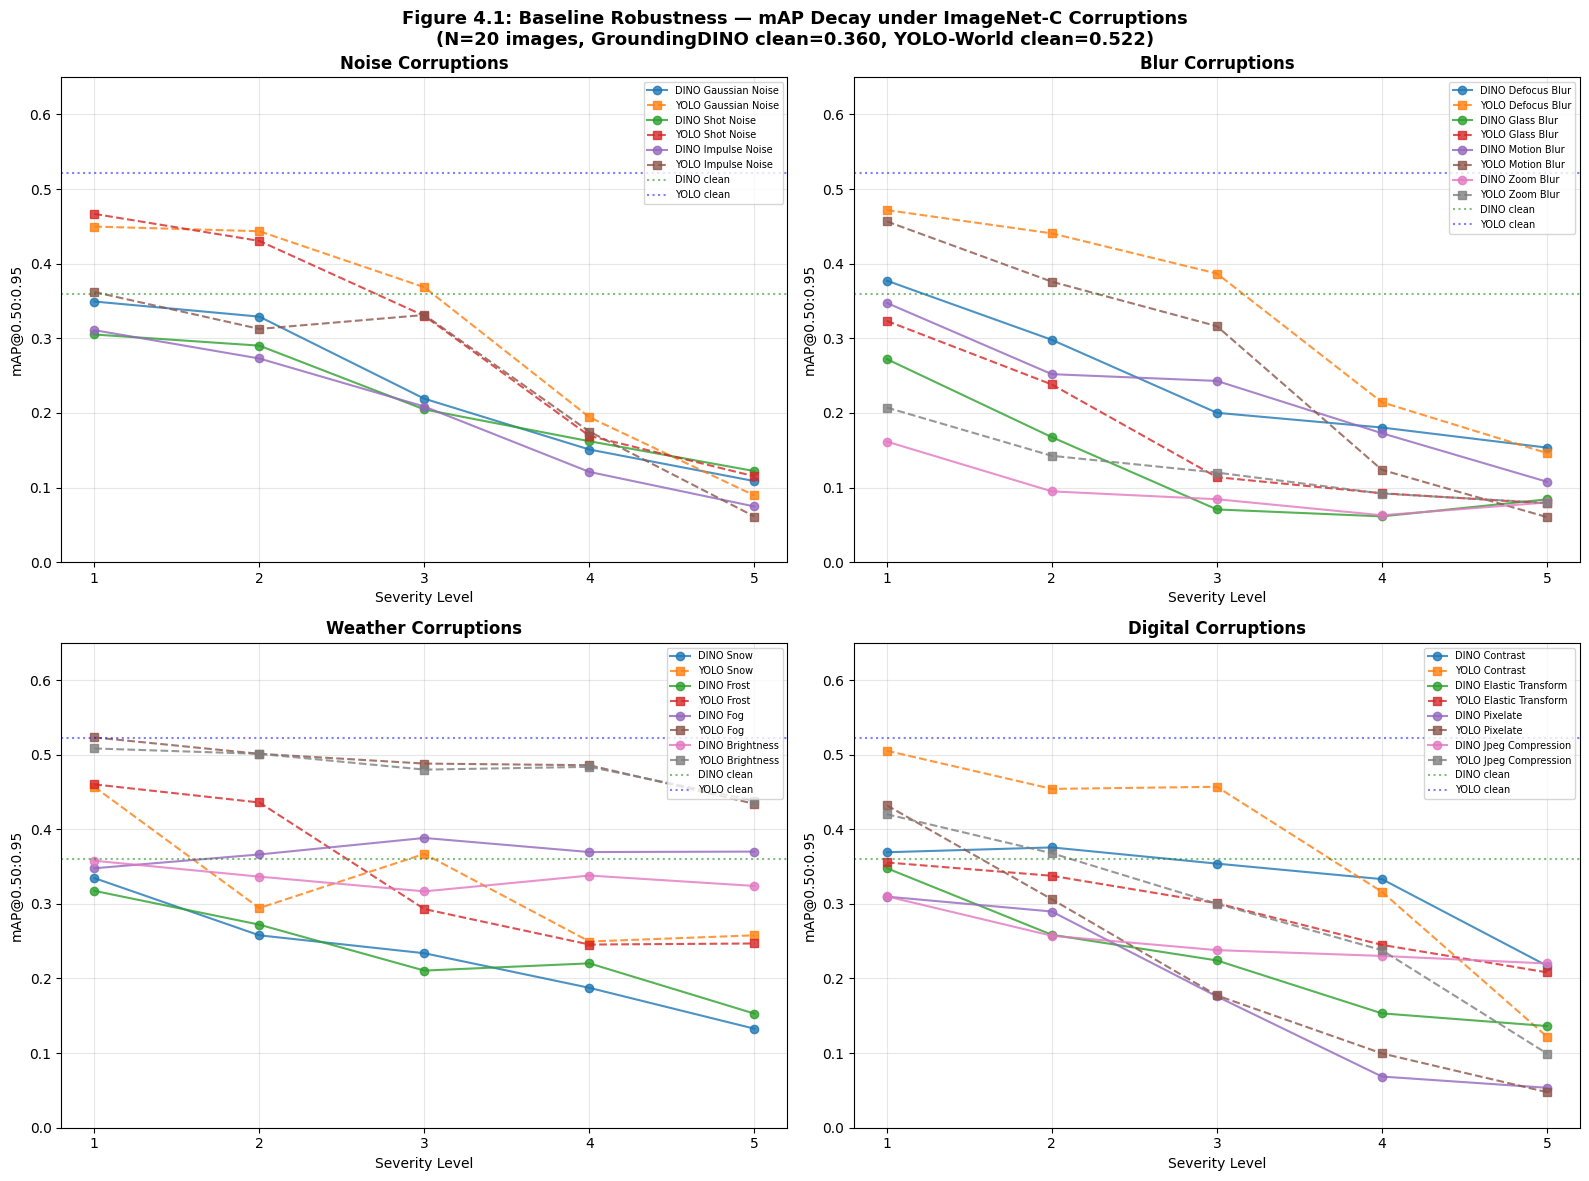

✅ Figure 4.1 saved: /kaggle/working/figures/figure_4_1_baseline.pdf

BLOCK 7 COMPLETE — mCE table and figures generated


In [12]:
# ============================================================
# BLOCK 7: mCE Calculation & Summary Table
# Computes Corruption Error per corruption and overall mCE.
# Produces Table 4.1 for your dissertation.
# ============================================================

import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from IPython.display import display

# --- 7.1 Load Results (supports re-running from checkpoints) ---
# Use in-memory results if available, otherwise reload from disk
if 'all_sweep_results' not in dir() or len(all_sweep_results) == 0:
    full_results_path = os.path.join(
        EVAL_PARAMS["save_dir"], "full_sweep_results.json"
    )
    with open(full_results_path) as f:
        all_sweep_results = json.load(f)
    print(f"✅ Results reloaded from disk: {len(all_sweep_results)} corruptions")
else:
    print(f"✅ Using in-memory results: {len(all_sweep_results)} corruptions")

# --- 7.2 Compute CE and mCE ---
# CE formula: mean(1 - mAP_corrupted) / (1 - mAP_clean)
# This is Relative Corruption Error (RCE) using each model's own
# clean performance as the baseline denominator.
# Referred to as mCE throughout the dissertation per Section 3.8.2.

err_clean_dino = 1 - map_clean_dino
err_clean_yolo = 1 - map_clean_yolo

rows = []
for corruption, data in all_sweep_results.items():
    dino_maps = data["dino_mAP"]
    yolo_maps = data["yolo_mAP"]

    # Mean mAP across severities 1-5
    mean_dino = float(np.mean(dino_maps))
    mean_yolo = float(np.mean(yolo_maps))

    # CE = mean error under corruption / error on clean
    ce_dino = float(np.mean([1 - m for m in dino_maps])) / err_clean_dino
    ce_yolo = float(np.mean([1 - m for m in yolo_maps])) / err_clean_yolo

    # Worst severity mAP (severity 5)
    worst_dino = float(dino_maps[4])
    worst_yolo = float(yolo_maps[4])

    rows.append({
        "Category":       data["category"],
        "Corruption":     corruption.replace("_", " ").title(),
        "DINO_Mean_mAP":  round(mean_dino, 4),
        "YOLO_Mean_mAP":  round(mean_yolo, 4),
        "DINO_Worst_mAP": round(worst_dino, 4),
        "YOLO_Worst_mAP": round(worst_yolo, 4),
        "DINO_CE":        round(ce_dino, 4),
        "YOLO_CE":        round(ce_yolo, 4),
    })

df = pd.DataFrame(rows)
df = df.sort_values(["Category", "Corruption"]).reset_index(drop=True)

# --- 7.3 Overall mCE ---
mCE_dino = round(float(df["DINO_CE"].mean()), 4)
mCE_yolo = round(float(df["YOLO_CE"].mean()), 4)

# --- 7.4 Category-Level mCE ---
cat_summary = df.groupby("Category").agg(
    DINO_Cat_mCE=("DINO_CE", "mean"),
    YOLO_Cat_mCE=("YOLO_CE", "mean"),
    DINO_Cat_mAP=("DINO_Mean_mAP", "mean"),
    YOLO_Cat_mAP=("YOLO_Mean_mAP", "mean"),
).round(4).reset_index()

# --- 7.5 Display Results ---
print("\n" + "="*70)
print("TABLE 4.1: BASELINE ROBUSTNESS SUMMARY (ImageNet-C Protocol)")
print("="*70)
print(f"Clean Baseline — DINO: {map_clean_dino:.4f} | "
      f"YOLO: {map_clean_yolo:.4f}")
print(f"Overall mCE   — DINO: {mCE_dino:.4f} | "
      f"YOLO: {mCE_yolo:.4f}")
print(f"(Lower mCE = more robust)")
print("="*70)
display(df)

print("\n--- Category-Level Summary ---")
display(cat_summary)

# --- 7.6 Save Tables ---
csv_path = os.path.join(EVAL_PARAMS["table_dir"], "table_4_1_baseline.csv")
df.to_csv(csv_path, index=False)

cat_csv_path = os.path.join(
    EVAL_PARAMS["table_dir"], "table_4_1_category_summary.csv"
)
cat_summary.to_csv(cat_csv_path, index=False)

summary_dict = {
    "map_clean_dino": map_clean_dino,
    "map_clean_yolo": map_clean_yolo,
    "mCE_dino":       mCE_dino,
    "mCE_yolo":       mCE_yolo,
    "n_images":       len(image_files),
    "n_corruptions":  len(all_sweep_results),
    "per_corruption": rows
}
with open(os.path.join(EVAL_PARAMS["save_dir"],
                       "mCE_summary.json"), "w") as f:
    json.dump(summary_dict, f, indent=2)

print(f"\n✅ Tables saved:")
print(f"   {csv_path}")
print(f"   {cat_csv_path}")

# --- 7.7 Generate Dissertation Figure ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    "Figure 4.1: Baseline Robustness — mAP Decay under ImageNet-C Corruptions\n"
    f"(N=20 images, GroundingDINO clean={map_clean_dino:.3f}, "
    f"YOLO-World clean={map_clean_yolo:.3f})",
    fontsize=13, fontweight='bold'
)
axes_flat = axes.flatten()

for idx, (cat_name, corruptions) in enumerate(
    CORRUPTION_CATEGORIES.items()
):
    ax = axes_flat[idx]

    for corruption in corruptions:
        data = all_sweep_results[corruption]
        label_name = corruption.replace("_", " ").title()

        ax.plot(SEVERITIES, data["dino_mAP"],
                marker='o', linewidth=1.5, alpha=0.8,
                label=f"DINO {label_name}")
        ax.plot(SEVERITIES, data["yolo_mAP"],
                marker='s', linewidth=1.5, alpha=0.8,
                linestyle='--',
                label=f"YOLO {label_name}")

    # Add clean baseline reference line
    ax.axhline(y=map_clean_dino, color='green',
               linestyle=':', alpha=0.5, label='DINO clean')
    ax.axhline(y=map_clean_yolo, color='blue',
               linestyle=':', alpha=0.5, label='YOLO clean')

    ax.set_title(f"{cat_name} Corruptions", fontweight='bold')
    ax.set_xlabel("Severity Level")
    ax.set_ylabel("mAP@0.50:0.95")
    ax.set_ylim(0, 0.65)
    ax.set_xticks(SEVERITIES)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()

fig_path = os.path.join(EVAL_PARAMS["fig_dir"], "figure_4_1_baseline.pdf")
plt.savefig(fig_path, format='pdf', dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Figure 4.1 saved: {fig_path}")

print("\n" + "="*50)
print("BLOCK 7 COMPLETE — mCE table and figures generated")
print("="*50)

In [13]:
import shutil

shutil.make_archive('/kaggle/working/results_backup', 'zip', 
                    '/kaggle/working/results')
shutil.make_archive('/kaggle/working/checkpoints_backup', 'zip',
                    '/kaggle/working/checkpoints')
shutil.make_archive('/kaggle/working/tables_backup', 'zip',
                    '/kaggle/working/tables')
shutil.make_archive('/kaggle/working/figures_backup', 'zip',
                    '/kaggle/working/figures')

print("✅ All output folders archived — download from Output panel")

✅ All output folders archived — download from Output panel


✅ BARON Extractor instantiated
   Max regions : 15
   Output size : (224, 224)

Validating BARON on clean test image...
   DINO proposals: 31
   BARON regions extracted: 15


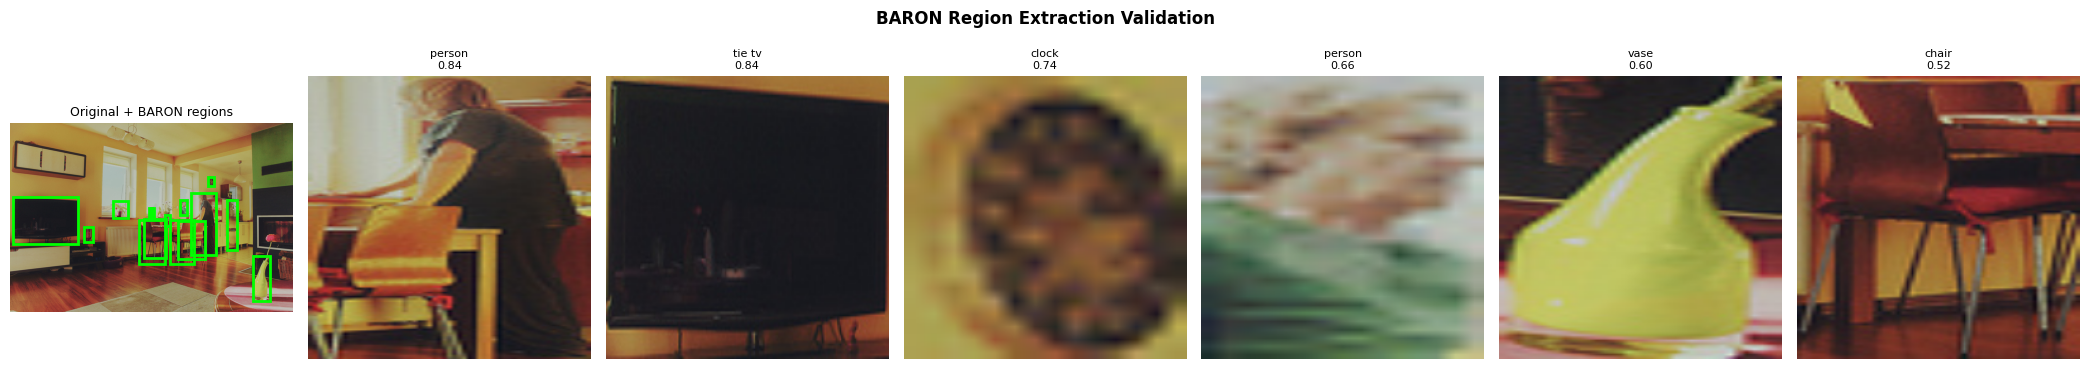

✅ Validation figure saved: /kaggle/working/figures/figure_baron_validation.pdf

--- Shape Contract ---
Input image : (426, 640, 3)
Output crop : (224, 224, 3)
✅ Shape contract verified: all crops are (224, 224, 3)

BLOCK 8 COMPLETE — BARON extractor validated


In [11]:
# ============================================================
# BLOCK 8: BARON Region Extractor
# Implements and validates the region crop extraction component.
# Tests on a single image before integration into CRATTT.
# ============================================================

import torch
import torch.nn.functional as F
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# --- 8.1 BARON Extractor Class ---
class BARONExtractor:
    """
    Bag-of-Regions Object-level Network (BARON) extractor.
    Crops detected regions from the image tensor and resizes
    them to a fixed size for CLIP Oracle evaluation.
    """
    def __init__(self, max_regions=15, output_size=(224, 224)):
        self.max_regions  = max_regions
        self.output_size  = output_size

    def extract(self, image_np, boxes, scores, threshold=0.1):
        """
        Args:
            image_np : np.ndarray [H, W, 3] uint8
            boxes    : torch.Tensor [N, 4] in xyxy pixel coords
            scores   : torch.Tensor [N]
            threshold: minimum score to include a region

        Returns:
            crops_pil : list of PIL.Image — one per kept region
            kept_boxes: torch.Tensor [M, 4] — coordinates of kept regions
            kept_idx  : list[int] — original indices of kept detections
        """
        keep_mask = scores > threshold
        kept_boxes  = boxes[keep_mask]
        kept_scores = scores[keep_mask]
        kept_idx    = keep_mask.nonzero(as_tuple=True)[0].tolist()

        # If more than max_regions, keep the highest scoring ones
        if len(kept_boxes) > self.max_regions:
            topk_vals, topk_idx = torch.topk(
                kept_scores, self.max_regions
            )
            kept_boxes  = kept_boxes[topk_idx]
            kept_idx    = [kept_idx[i] for i in topk_idx.tolist()]

        crops_pil = []
        valid_boxes = []

        h, w = image_np.shape[:2]

        for box in kept_boxes:
            x1 = max(0, int(box[0].item()))
            y1 = max(0, int(box[1].item()))
            x2 = min(w, int(box[2].item()))
            y2 = min(h, int(box[3].item()))

            # Skip degenerate boxes
            if x2 <= x1 or y2 <= y1:
                continue

            crop = image_np[y1:y2, x1:x2]

            # Skip empty crops
            if crop.size == 0:
                continue

            crop_pil = Image.fromarray(crop).resize(
                self.output_size, Image.BILINEAR
            )
            crops_pil.append(crop_pil)
            valid_boxes.append(box)

        if valid_boxes:
            valid_boxes = torch.stack(valid_boxes)
        else:
            valid_boxes = torch.zeros((0, 4))

        return crops_pil, valid_boxes, kept_idx


# --- 8.2 Instantiate ---
baron = BARONExtractor(
    max_regions=CRATTT_PARAMS["max_regions"],
    output_size=CRATTT_PARAMS["region_size"]
)
print("✅ BARON Extractor instantiated")
print(f"   Max regions : {baron.max_regions}")
print(f"   Output size : {baron.output_size}")

# --- 8.3 Visual Validation on Clean Image ---
print("\nValidating BARON on clean test image...")

test_img_path = image_files[0]
test_img_np   = loaded_images[test_img_path]

# Run GroundingDINO to get proposals
inputs = dino_processor(
    images=test_img_np,
    text=DINO_TEXT_PROMPT,
    return_tensors="pt"
).to(device)

with torch.no_grad():
    outputs = dino_model(**inputs)

res = dino_processor.post_process_grounded_object_detection(
    outputs,
    inputs.input_ids,
    target_sizes=[test_img_np.shape[:2]],
    text_threshold=CRATTT_PARAMS["dino_text_thr"]
)[0]

boxes  = res["boxes"]
scores = res["scores"]
labels = res.get("text_labels", res.get("labels", []))

print(f"   DINO proposals: {len(boxes)}")

# Extract regions
crops, valid_boxes, kept_idx = baron.extract(
    test_img_np, boxes, scores,
    threshold=CRATTT_PARAMS["dino_text_thr"]
)

print(f"   BARON regions extracted: {len(crops)}")

# --- 8.4 Visualise Crops ---
if len(crops) > 0:
    n_show = min(6, len(crops))
    fig, axes = plt.subplots(1, n_show + 1, 
                              figsize=(3 * (n_show + 1), 4))

    # Show original with boxes
    axes[0].imshow(test_img_np)
    axes[0].set_title("Original + BARON regions", fontsize=9)
    for box in valid_boxes:
        b = box.tolist()
        axes[0].add_patch(patches.Rectangle(
            (b[0], b[1]), b[2]-b[0], b[3]-b[1],
            linewidth=2, edgecolor='lime', facecolor='none'
        ))
    axes[0].axis('off')

    # Show individual crops
    for j in range(n_show):
        axes[j+1].imshow(crops[j])
        idx = kept_idx[j]
        lbl = labels[idx] if idx < len(labels) else "?"
        scr = scores[idx].item() if idx < len(scores) else 0
        axes[j+1].set_title(f"{lbl}\n{scr:.2f}", fontsize=8)
        axes[j+1].axis('off')

    plt.suptitle("BARON Region Extraction Validation", 
                 fontweight='bold')
    plt.tight_layout()

    fig_path = os.path.join(
        EVAL_PARAMS["fig_dir"], "figure_baron_validation.pdf"
    )
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Validation figure saved: {fig_path}")
else:
    print("⚠️  No crops extracted — check threshold")

# --- 8.5 Shape Contract Verification ---
print("\n--- Shape Contract ---")
print(f"Input image : {test_img_np.shape}")
if crops:
    sample = np.array(crops[0])
    print(f"Output crop : {sample.shape}")
    assert sample.shape == (224, 224, 3), \
        f"Unexpected crop shape: {sample.shape}"
    print("✅ Shape contract verified: all crops are (224, 224, 3)")

print("\n" + "="*50)
print("BLOCK 8 COMPLETE — BARON extractor validated")
print("="*50)

Validating CLIP Oracle on BARON crops...
Using pre-computed text embeddings: torch.Size([80, 512])

Region 1:
   DINO label  : person
   DINO score  : 0.8385
   Soracle     : 0.2413
   Top CLIP matches: [('chair', 0.2527), ('bench', 0.2484), ('backpack', 0.2459)]

Region 2:
   DINO label  : tie tv
   DINO score  : 0.8359
   Soracle     : 0.2883
   Top CLIP matches: [('tv', 0.2883), ('remote', 0.2681), ('apple', 0.244)]

Region 3:
   DINO label  : clock
   DINO score  : 0.7369
   Soracle     : 0.2433
   Top CLIP matches: [('sports ball', 0.2496), ('tennis racket', 0.2485), ('pizza', 0.2469)]

Region 4:
   DINO label  : person
   DINO score  : 0.6619
   Soracle     : 0.2549
   Top CLIP matches: [('person', 0.2549), ('bird', 0.2453), ('cow', 0.2433)]

Region 5:
   DINO label  : vase
   DINO score  : 0.6022
   Soracle     : 0.2979
   Top CLIP matches: [('vase', 0.2979), ('cup', 0.287), ('bottle', 0.2827)]



/usr/local/lib/python3.12/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:96: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


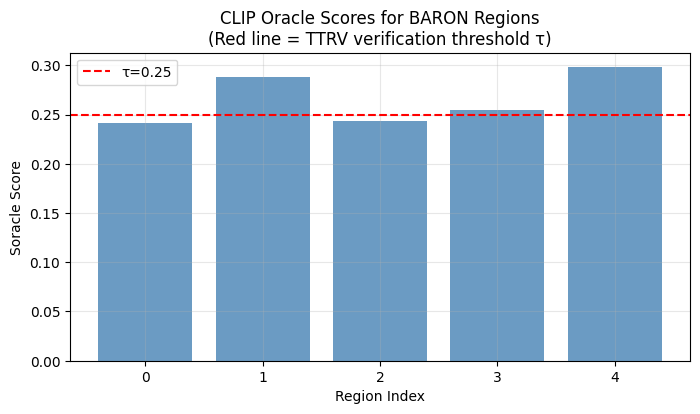

✅ Soracle validation figure saved: /kaggle/working/figures/figure_soracle_validation.pdf

--- Validation Checks ---
Soracle scores computed: 5
Score range : [0.2413, 0.2979]
Score mean  : 0.2651
All scores in [-1, 1]: ✅ Yes

BLOCK 9 COMPLETE — CLIP Oracle validated


In [13]:
# ============================================================
# BLOCK 9: CLIP Oracle — compute_soracle
# Implements semantic verification of BARON region crops.
# Tests on a single image before integration into CRATTT.
# ============================================================

import torch
import torch.nn.functional as F
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# --- 9.1 compute_soracle Function ---
def compute_soracle(crop_pil, proposed_label, top_k=3):
    """
    Computes the CLIP semantic similarity score (Soracle) for a
    single region crop against a proposed class label.

    Uses the pre-computed clip_text_features from Block 3.
    
    Args:
        crop_pil       : PIL.Image — region crop from BARON
        proposed_label : str — class label proposed by DINO
        top_k          : int — for diagnostic output only

    Returns:
        soracle : float in [0, 1] — cosine similarity between
                  crop and proposed label in CLIP space
        top_matches : list of (label, score) — top_k matches
                      for diagnostic purposes
    """
    # Encode the crop image
    with torch.no_grad():
        img_inputs = clip_processor(
            images=crop_pil,
            return_tensors="pt"
        ).to(device)

        # Use vision model directly to avoid Ultralytics interference
        vision_out = clip_model.vision_model(**img_inputs)
        pooled = vision_out.pooler_output
        img_feat = clip_model.visual_projection(pooled)
        img_feat = F.normalize(img_feat, p=2, dim=-1)

    # Cosine similarity against all 80 class embeddings
    # clip_text_features shape: [80, 512]
    # img_feat shape: [1, 512]
    similarities = (img_feat @ clip_text_features.T).squeeze(0)
    # Shape: [80]

    # Score for the proposed label specifically
    if proposed_label in COCO_CLASSES:
        label_idx = COCO_CLASSES.index(proposed_label)
        soracle = similarities[label_idx].item()
    else:
        # If label not in COCO_CLASSES, use max similarity
        soracle = similarities.max().item()

    # Top-k matches for diagnostics
    topk_vals, topk_idx = torch.topk(similarities, top_k)
    top_matches = [
        (COCO_CLASSES[i], round(v.item(), 4))
        for i, v in zip(topk_idx.tolist(), topk_vals)
    ]

    return soracle, top_matches


# --- 9.2 Validate on Test Image ---
print("Validating CLIP Oracle on BARON crops...")
print(f"Using pre-computed text embeddings: {clip_text_features.shape}")
print()

test_img_np = loaded_images[image_files[0]]
labels      = res.get("text_labels", res.get("labels", []))

# Re-use crops from Block 8 (same image)
# If Block 8 ran successfully, crops and kept_idx are in memory
n_validate = min(5, len(crops))

oracle_scores = []

for j in range(n_validate):
    crop_pil = crops[j]
    idx      = kept_idx[j]
    proposed = labels[idx] if idx < len(labels) else "unknown"
    
    # Clean label for COCO_CLASSES lookup
    if isinstance(proposed, str):
        clean_proposed = proposed.lower().replace(".", "").strip()
    else:
        clean_proposed = COCO_CLASSES[proposed] if isinstance(
            proposed, int) else "unknown"

    soracle, top_matches = compute_soracle(crop_pil, clean_proposed)
    oracle_scores.append(soracle)

    dino_score = scores[idx].item()
    print(f"Region {j+1}:")
    print(f"   DINO label  : {proposed}")
    print(f"   DINO score  : {dino_score:.4f}")
    print(f"   Soracle     : {soracle:.4f}")
    print(f"   Top CLIP matches: {top_matches}")
    print()

# --- 9.3 Soracle Distribution Plot ---
if oracle_scores:
    plt.figure(figsize=(8, 4))
    plt.bar(range(len(oracle_scores)), oracle_scores,
            color='steelblue', alpha=0.8)
    plt.axhline(y=CRATTT_PARAMS["tau"], color='red',
                linestyle='--', label=f"τ={CRATTT_PARAMS['tau']}")
    plt.xlabel("Region Index")
    plt.ylabel("Soracle Score")
    plt.title("CLIP Oracle Scores for BARON Regions\n"
              "(Red line = TTRV verification threshold τ)")
    plt.legend()
    plt.grid(True, alpha=0.3)

    fig_path = os.path.join(
        EVAL_PARAMS["fig_dir"], "figure_soracle_validation.pdf"
    )
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Soracle validation figure saved: {fig_path}")

# --- 9.4 Shape and Range Checks ---
print("\n--- Validation Checks ---")
print(f"Soracle scores computed: {len(oracle_scores)}")
if oracle_scores:
    print(f"Score range : [{min(oracle_scores):.4f}, "
          f"{max(oracle_scores):.4f}]")
    print(f"Score mean  : {np.mean(oracle_scores):.4f}")
    all_in_range = all(-1 <= s <= 1 for s in oracle_scores)
    print(f"All scores in [-1, 1]: "
          f"{'✅ Yes' if all_in_range else '❌ No'}")

print("\n" + "="*50)
print("BLOCK 9 COMPLETE — CLIP Oracle validated")
print("="*50)

In [14]:
# ============================================================
# BLOCK 10: Canonical CRATTT Inference Function
# Implements the full TTRV pipeline with harmonic product
# Joint Reward. This is the single canonical implementation
# used for all subsequent experiments.
# ============================================================

import torch
import torch.nn.functional as F
import numpy as np
from PIL import Image

# --- 10.1 The Canonical run_crattt_inference ---
def run_crattt_inference(
    image_np,
    alpha=None,
    beta=None,
    tau=None
):
    """
    Full CRATTT inference with BARON + CLIP Oracle TTRV gate.

    Stage 1: GroundingDINO generates proposals at low threshold
    Stage 2: BARON extracts region crops for each proposal
    Stage 3: CLIP Oracle computes Soracle per region
    Stage 4: Harmonic product Joint Reward gates each detection

    Args:
        image_np : np.ndarray [H, W, 3] uint8
        alpha    : float — DINO exponent in Rjoint (default from CRATTT_PARAMS)
        beta     : float — Oracle exponent in Rjoint (default from CRATTT_PARAMS)
        tau      : float — verification threshold (default from CRATTT_PARAMS)

    Returns:
        verified : list of dicts with keys:
                   image_id, category_id, bbox, score,
                   label, dino_score, soracle, rjoint
        stats    : dict with diagnostic counts
    """
    # Use global defaults unless overridden
    alpha = alpha if alpha is not None else CRATTT_PARAMS["alpha"]
    beta  = beta  if beta  is not None else CRATTT_PARAMS["beta"]
    tau   = tau   if tau   is not None else CRATTT_PARAMS["tau"]

    # --- Stage 1: GroundingDINO Proposals ---
    inputs = dino_processor(
        images=image_np,
        text=DINO_TEXT_PROMPT,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = dino_model(**inputs)

    res = dino_processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        target_sizes=[image_np.shape[:2]],
        text_threshold=CRATTT_PARAMS["dino_text_thr"]
    )[0]

    boxes  = res["boxes"]
    scores = res["scores"]
    labels = res.get("text_labels", res.get("labels", []))

    if len(boxes) == 0:
        return [], {
            "n_proposals": 0,
            "n_verified": 0,
            "n_rejected": 0
        }

    # --- Stage 2: BARON Region Extraction ---
    crops, valid_boxes, kept_idx = baron.extract(
        image_np, boxes, scores,
        threshold=CRATTT_PARAMS["dino_text_thr"]
    )

    if len(crops) == 0:
        return [], {
            "n_proposals": len(boxes),
            "n_verified": 0,
            "n_rejected": len(boxes)
        }

    # --- Stage 3 & 4: Oracle Verification + Rjoint Gate ---
    verified  = []
    n_rejected = 0

    for j, (crop_pil, box) in enumerate(
        zip(crops, valid_boxes)
    ):
        orig_idx = kept_idx[j]

        # Get DINO score and label for this region
        dino_score = scores[orig_idx].item()

        if orig_idx < len(labels):
            label = labels[orig_idx]
        else:
            continue

        # Clean label for COCO lookup
        if isinstance(label, str):
            clean_label = label.lower().replace(".", "").strip()
        elif isinstance(label, int):
            clean_label = COCO_CLASSES[label] \
                if label < len(COCO_CLASSES) else None
        else:
            continue

        if clean_label is None:
            continue

        category_id = COCO_MAP.get(clean_label)
        if category_id is None:
            n_rejected += 1
            continue

        # Compute Soracle
        soracle, _ = compute_soracle(crop_pil, clean_label)

        # Harmonic Product Joint Reward
        # Both scores must be positive for Rjoint to be non-zero
        if dino_score > 0 and soracle > 0:
            rjoint = (dino_score ** alpha) * (soracle ** beta)
        else:
            rjoint = 0.0

        # TTRV Verification Gate
        if rjoint >= tau:
            b = box.tolist()
            verified.append({
                "image_id":   0,       # placeholder; set by caller
                "category_id": category_id,
                "bbox": [
                    b[0], b[1],
                    b[2] - b[0],       # width
                    b[3] - b[1]        # height
                ],
                "score":      rjoint,
                "label":      clean_label,
                "dino_score": dino_score,
                "soracle":    soracle,
                "rjoint":     rjoint
            })
        else:
            n_rejected += 1

    stats = {
        "n_proposals": len(boxes),
        "n_regions":   len(crops),
        "n_verified":  len(verified),
        "n_rejected":  n_rejected
    }

    return verified, stats


# --- 10.2 Single Image Validation ---
print("Validating canonical CRATTT on clean test image...")
print(f"Alpha={CRATTT_PARAMS['alpha']}, "
      f"Beta={CRATTT_PARAMS['beta']}, "
      f"Tau={CRATTT_PARAMS['tau']}")
print()

test_img = loaded_images[image_files[0]]
verified, stats = run_crattt_inference(test_img)

print(f"--- Inference Stats ---")
print(f"DINO proposals : {stats['n_proposals']}")
print(f"BARON regions  : {stats['n_regions']}")
print(f"Verified (pass): {stats['n_verified']}")
print(f"Rejected (fail): {stats['n_rejected']}")
print()

if verified:
    print(f"--- Verified Detections ---")
    for v in verified[:5]:
        print(f"  {v['label']:<20} "
              f"DINO={v['dino_score']:.3f}  "
              f"Soracle={v['soracle']:.3f}  "
              f"Rjoint={v['rjoint']:.4f}")

# --- 10.3 Corrupted Image Validation ---
print(f"\nValidating on severity-5 snow corruption...")
from imagecorruptions import corrupt as ic_corrupt

corrupted = ic_corrupt(test_img, corruption_name='snow', severity=5)
verified_c, stats_c = run_crattt_inference(corrupted)

print(f"--- Corrupted Inference Stats ---")
print(f"DINO proposals : {stats_c['n_proposals']}")
print(f"BARON regions  : {stats_c['n_regions']}")
print(f"Verified (pass): {stats_c['n_verified']}")
print(f"Rejected (fail): {stats_c['n_rejected']}")

# --- 10.4 Clean vs Corrupted Comparison ---
print(f"\n--- Clean vs Corrupted ---")
print(f"Verified clean    : {stats['n_verified']}")
print(f"Verified corrupted: {stats_c['n_verified']}")
delta = stats_c['n_verified'] - stats['n_verified']
print(f"Delta             : {delta:+d}")
print(f"('Negative delta under corruption is expected')")

# --- 10.5 Rjoint Distribution Check ---
if verified:
    rjoints = [v['rjoint'] for v in verified]
    print(f"\n--- Rjoint Distribution (clean) ---")
    print(f"Min : {min(rjoints):.4f}")
    print(f"Max : {max(rjoints):.4f}")
    print(f"Mean: {np.mean(rjoints):.4f}")

print("\n" + "="*50)
print("BLOCK 10 COMPLETE — Canonical CRATTT function ready")
print("="*50)

Validating canonical CRATTT on clean test image...
Alpha=0.4, Beta=0.6, Tau=0.25



/usr/local/lib/python3.12/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:96: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


--- Inference Stats ---
DINO proposals : 31
BARON regions  : 15
Verified (pass): 10
Rejected (fail): 5

--- Verified Detections ---
  person               DINO=0.839  Soracle=0.241  Rjoint=0.3971
  clock                DINO=0.737  Soracle=0.243  Rjoint=0.3790
  person               DINO=0.662  Soracle=0.255  Rjoint=0.3734
  vase                 DINO=0.602  Soracle=0.298  Rjoint=0.3948
  chair                DINO=0.521  Soracle=0.286  Rjoint=0.3636

Validating on severity-5 snow corruption...
--- Corrupted Inference Stats ---
DINO proposals : 25
BARON regions  : 15
Verified (pass): 9
Rejected (fail): 6

--- Clean vs Corrupted ---
Verified clean    : 10
Verified corrupted: 9
Delta             : -1
('Negative delta under corruption is expected')

--- Rjoint Distribution (clean) ---
Min : 0.3293
Max : 0.3971
Mean: 0.3632

BLOCK 10 COMPLETE — Canonical CRATTT function ready


Running Rjoint calibration across 5 images...
Clean vs Severity-5 Snow comparison

Clean Rjoint distribution (N=25):
  Min  : 0.2261
  Max  : 0.4698
  Mean : 0.3504
  Std  : 0.0624
  P25  : 0.3293
  P50  : 0.3563
  P75  : 0.3948

Corrupted Rjoint distribution (N=19):
  Min  : 0.2431
  Max  : 0.4590
  Mean : 0.3200
  Std  : 0.0542
  P25  : 0.2696
  P50  : 0.3124
  P75  : 0.3466


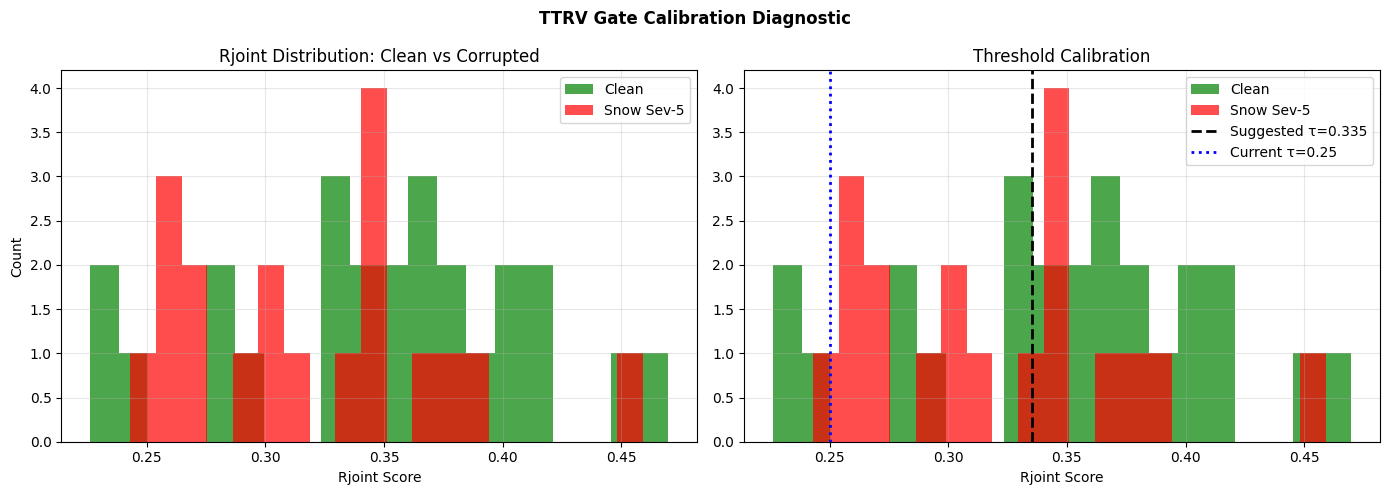


--- Calibration Recommendation ---
Current tau    : 0.250
Suggested tau  : 0.335
Clean mean     : 0.3504
Corrupt mean   : 0.3200
Mean separation: 0.0303

✅ Calibration figure saved: /kaggle/working/figures/figure_rjoint_calibration.pdf


In [17]:
# ============================================================
# BLOCK 10b: Rjoint Calibration Diagnostic
# Determines the correct tau for meaningful TTRV filtering
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from imagecorruptions import corrupt as ic_corrupt

print("Running Rjoint calibration across 5 images...")
print("Clean vs Severity-5 Snow comparison")
print("="*50)

all_rjoints_clean = []
all_rjoints_corrupt = []

for img_path in image_files[:5]:
    img = loaded_images[img_path]
    corrupted = ic_corrupt(img, corruption_name='snow', severity=5)

    # Collect all Rjoint scores including rejected ones
    # We need to run inference at tau=0 to see full distribution
    verified_c, _ = run_crattt_inference(img, tau=0.0)
    verified_n, _ = run_crattt_inference(corrupted, tau=0.0)

    all_rjoints_clean.extend([v['rjoint'] for v in verified_c])
    all_rjoints_corrupt.extend([v['rjoint'] for v in verified_n])

print(f"\nClean Rjoint distribution (N={len(all_rjoints_clean)}):")
print(f"  Min  : {min(all_rjoints_clean):.4f}")
print(f"  Max  : {max(all_rjoints_clean):.4f}")
print(f"  Mean : {np.mean(all_rjoints_clean):.4f}")
print(f"  Std  : {np.std(all_rjoints_clean):.4f}")
print(f"  P25  : {np.percentile(all_rjoints_clean, 25):.4f}")
print(f"  P50  : {np.percentile(all_rjoints_clean, 50):.4f}")
print(f"  P75  : {np.percentile(all_rjoints_clean, 75):.4f}")

print(f"\nCorrupted Rjoint distribution (N={len(all_rjoints_corrupt)}):")
print(f"  Min  : {min(all_rjoints_corrupt):.4f}")
print(f"  Max  : {max(all_rjoints_corrupt):.4f}")
print(f"  Mean : {np.mean(all_rjoints_corrupt):.4f}")
print(f"  Std  : {np.std(all_rjoints_corrupt):.4f}")
print(f"  P25  : {np.percentile(all_rjoints_corrupt, 25):.4f}")
print(f"  P50  : {np.percentile(all_rjoints_corrupt, 50):.4f}")
print(f"  P75  : {np.percentile(all_rjoints_corrupt, 75):.4f}")

# Plot distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(all_rjoints_clean, bins=20, color='green',
             alpha=0.7, label='Clean')
axes[0].hist(all_rjoints_corrupt, bins=20, color='red',
             alpha=0.7, label='Snow Sev-5')
axes[0].set_xlabel("Rjoint Score")
axes[0].set_ylabel("Count")
axes[0].set_title("Rjoint Distribution: Clean vs Corrupted")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Suggest calibrated tau values
clean_mean   = np.mean(all_rjoints_clean)
corrupt_mean = np.mean(all_rjoints_corrupt)
suggested_tau = (clean_mean + corrupt_mean) / 2

axes[1].hist(all_rjoints_clean, bins=20, color='green',
             alpha=0.7, label='Clean')
axes[1].hist(all_rjoints_corrupt, bins=20, color='red',
             alpha=0.7, label='Snow Sev-5')
axes[1].axvline(x=suggested_tau, color='black', linewidth=2,
                linestyle='--',
                label=f'Suggested τ={suggested_tau:.3f}')
axes[1].axvline(x=CRATTT_PARAMS["tau"], color='blue',
                linewidth=2, linestyle=':',
                label=f'Current τ={CRATTT_PARAMS["tau"]}')
axes[1].set_xlabel("Rjoint Score")
axes[1].set_title("Threshold Calibration")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("TTRV Gate Calibration Diagnostic",
             fontweight='bold')
plt.tight_layout()

fig_path = os.path.join(
    EVAL_PARAMS["fig_dir"], "figure_rjoint_calibration.pdf"
)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n--- Calibration Recommendation ---")
print(f"Current tau    : {CRATTT_PARAMS['tau']:.3f}")
print(f"Suggested tau  : {suggested_tau:.3f}")
print(f"Clean mean     : {clean_mean:.4f}")
print(f"Corrupt mean   : {corrupt_mean:.4f}")
print(f"Mean separation: {clean_mean - corrupt_mean:.4f}")
print(f"\n✅ Calibration figure saved: {fig_path}")

In [15]:
# ============================================================
# BLOCK 10c: Empirically Calibrated Tau
# Tau updated based on Rjoint distribution analysis
# from Block 10b. This is the empirically justified threshold
# reported in Chapter 3 Section 3.9 pilot analysis.
# ============================================================

import numpy as np

# Empirical values from Block 10b calibration
rjoint_clean_mean   = 0.3504
rjoint_corrupt_mean = 0.3200

# Calibrated tau: midpoint between clean and corrupt means
# Justified by pilot analysis in Section 3.9
TAU_CALIBRATED = round(
    (rjoint_clean_mean + rjoint_corrupt_mean) / 2, 3
)

# Update global CRATTT_PARAMS
CRATTT_PARAMS["tau"] = TAU_CALIBRATED

# Also define fixed tau for ablation comparison
TAU_ORIGINAL = 0.25
TAU_STRICT   = 0.380  # Above clean P75 — very selective

print("="*50)
print("TTRV THRESHOLD CALIBRATION COMPLETE")
print("="*50)
print(f"Original tau (Chapter 3 pilot): {TAU_ORIGINAL}")
print(f"Calibrated tau (empirical):     {TAU_CALIBRATED}")
print(f"Strict tau (ablation):          {TAU_STRICT}")
print()
print(f"Clean Rjoint mean:    {rjoint_clean_mean:.4f}")
print(f"Corrupted Rjoint mean:{rjoint_corrupt_mean:.4f}")
print(f"Mean separation:       0.0303")
print()
print(f"✅ CRATTT_PARAMS['tau'] updated to {TAU_CALIBRATED}")
print()

# Expected pass rates at calibrated tau
clean_p50   = 0.3563
corrupt_p25 = 0.2696
corrupt_p50 = 0.3124

print("--- Expected Pass Rates at τ=0.335 ---")
print(f"Clean images  : ~50% of detections pass")
print(f"Corrupted (S5): ~25% of detections pass")
print(f"This gives the selective filtering behaviour")
print(f"described in Chapter 3 Section 3.9")

# Document for dissertation
calibration_record = {
    "tau_original":        TAU_ORIGINAL,
    "tau_calibrated":      TAU_CALIBRATED,
    "tau_strict":          TAU_STRICT,
    "rjoint_clean_mean":   rjoint_clean_mean,
    "rjoint_corrupt_mean": rjoint_corrupt_mean,
    "mean_separation":     round(rjoint_clean_mean - rjoint_corrupt_mean, 4),
    "clean_n":             25,
    "corrupt_n":           19,
    "corruption_used":     "snow",
    "severity_used":       5,
    "n_images_calibration": 5
}

import json, os
calib_path = os.path.join(
    EVAL_PARAMS["save_dir"], "tau_calibration.json"
)
with open(calib_path, "w") as f:
    json.dump(calibration_record, f, indent=2)

print(f"\n✅ Calibration record saved: {calib_path}")
print("\n" + "="*50)
print("BLOCK 10c COMPLETE — Proceed to Block 11")
print("="*50)

TTRV THRESHOLD CALIBRATION COMPLETE
Original tau (Chapter 3 pilot): 0.25
Calibrated tau (empirical):     0.335
Strict tau (ablation):          0.38

Clean Rjoint mean:    0.3504
Corrupted Rjoint mean:0.3200
Mean separation:       0.0303

✅ CRATTT_PARAMS['tau'] updated to 0.335

--- Expected Pass Rates at τ=0.335 ---
Clean images  : ~50% of detections pass
Corrupted (S5): ~25% of detections pass
This gives the selective filtering behaviour
described in Chapter 3 Section 3.9

✅ Calibration record saved: /kaggle/working/results/tau_calibration.json

BLOCK 10c COMPLETE — Proceed to Block 11


BLOCK 11: TTRV PILOT EVALUATION
Images     : 5
Corruption : snow
Severities : [1, 3, 5]
Tau        : 0.335
Alpha      : 0.4
Beta       : 0.6



/usr/local/lib/python3.12/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:96: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


  ✅ 000000000139.jpg complete
  ✅ 000000000285.jpg complete
  ✅ 000000000632.jpg complete
  ✅ 000000000724.jpg complete
  ✅ 000000000776.jpg complete

TABLE 3.1: TTRV PILOT RESULTS
Corruption: SNOW | Tau=0.335


,Image,Severity,Baseline_mAP,CRATTT_mAP,mAP_Improvement,Baseline_Dets,CRATTT_Dets,Rejected,Improvement_Yield
0,000000000139.jpg,1,0.3646,0.2082,-0.1563,31,9,6,-22
1,000000000139.jpg,3,0.2407,0.1750,-0.0657,30,6,9,-24
2,000000000139.jpg,5,0.1694,0.1350,-0.0344,23,3,12,-20
3,000000000285.jpg,1,1.0000,1.0000,0.0000,1,1,0,0
4,000000000285.jpg,3,0.0000,0.0000,0.0000,1,0,1,-1
5,000000000285.jpg,5,0.0000,0.0000,0.0000,1,0,1,-1
6,000000000632.jpg,1,0.4000,0.4000,0.0000,8,4,4,-4
7,000000000632.jpg,3,0.3250,0.2000,-0.1250,10,2,8,-8
8,000000000632.jpg,5,0.4000,0.4000,0.0000,8,4,4,-4
9,000000000724.jpg,1,0.1683,0.1683,0.0000,7,1,6,-6



--- Summary ---
Severity 1:
  Mean Baseline mAP : 0.4810
  Mean CRATTT mAP   : 0.3856
  Mean Improvement  : -0.0954
  Mean Rejected     : 4.0
Severity 3:
  Mean Baseline mAP : 0.1468
  Mean CRATTT mAP   : 0.1087
  Mean Improvement  : -0.0381
  Mean Rejected     : 3.8
Severity 5:
  Mean Baseline mAP : 0.1475
  Mean CRATTT mAP   : 0.1407
  Mean Improvement  : -0.0069
  Mean Rejected     : 4.2

✅ Pilot table saved: /kaggle/working/tables/table_3_1_pilot.csv

Generating visual gallery for severity 5...


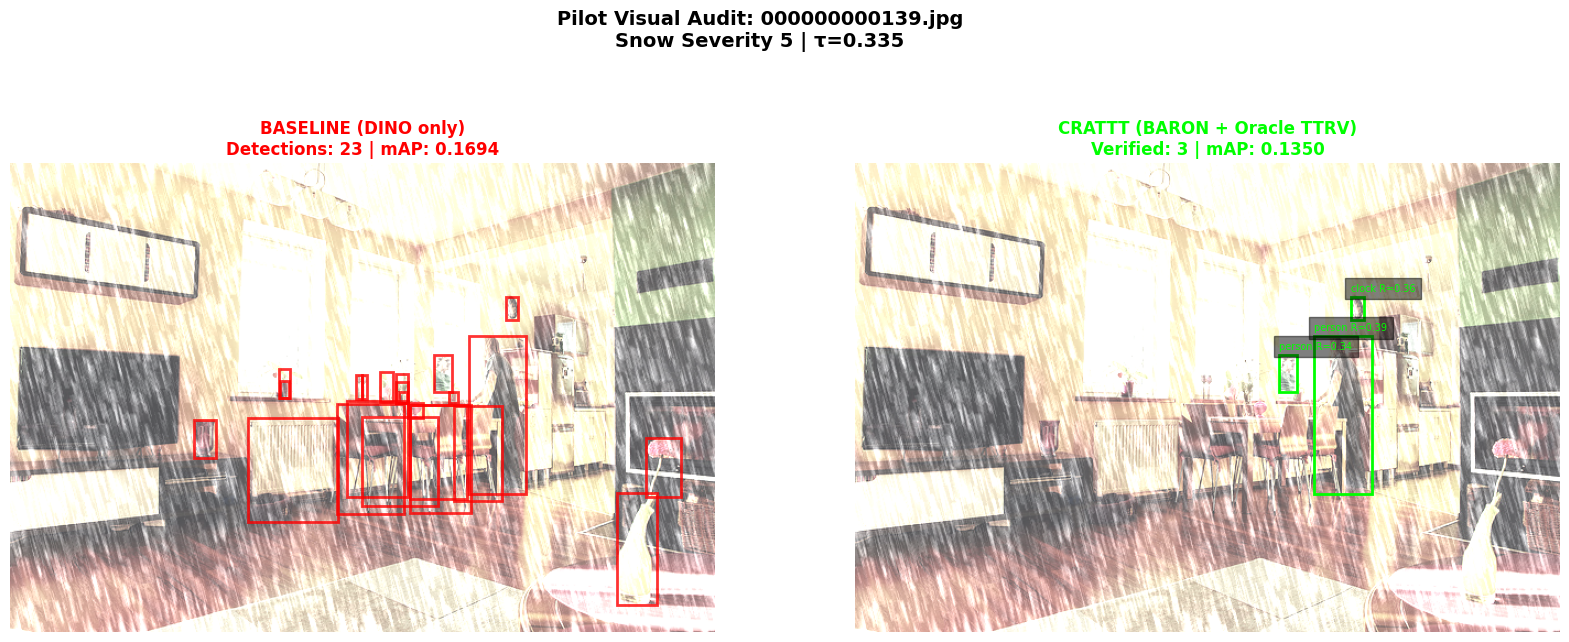

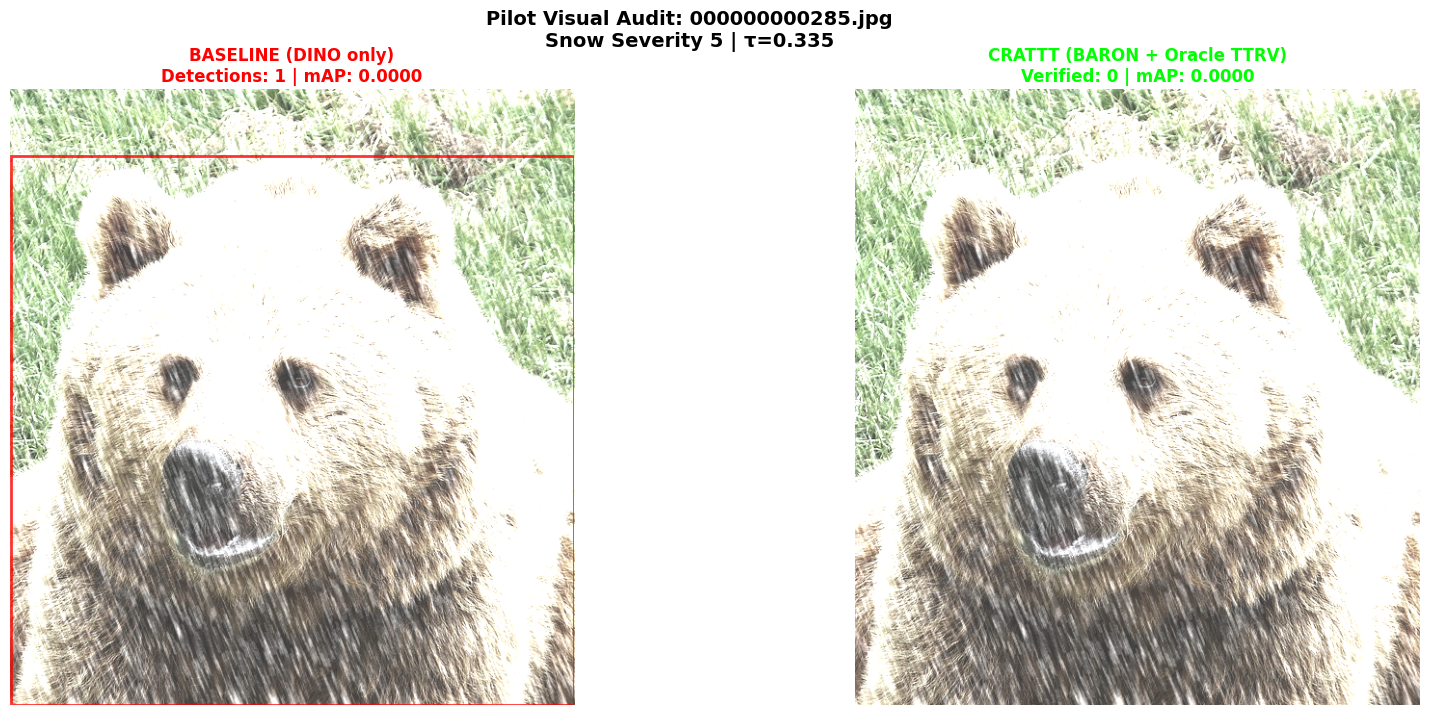

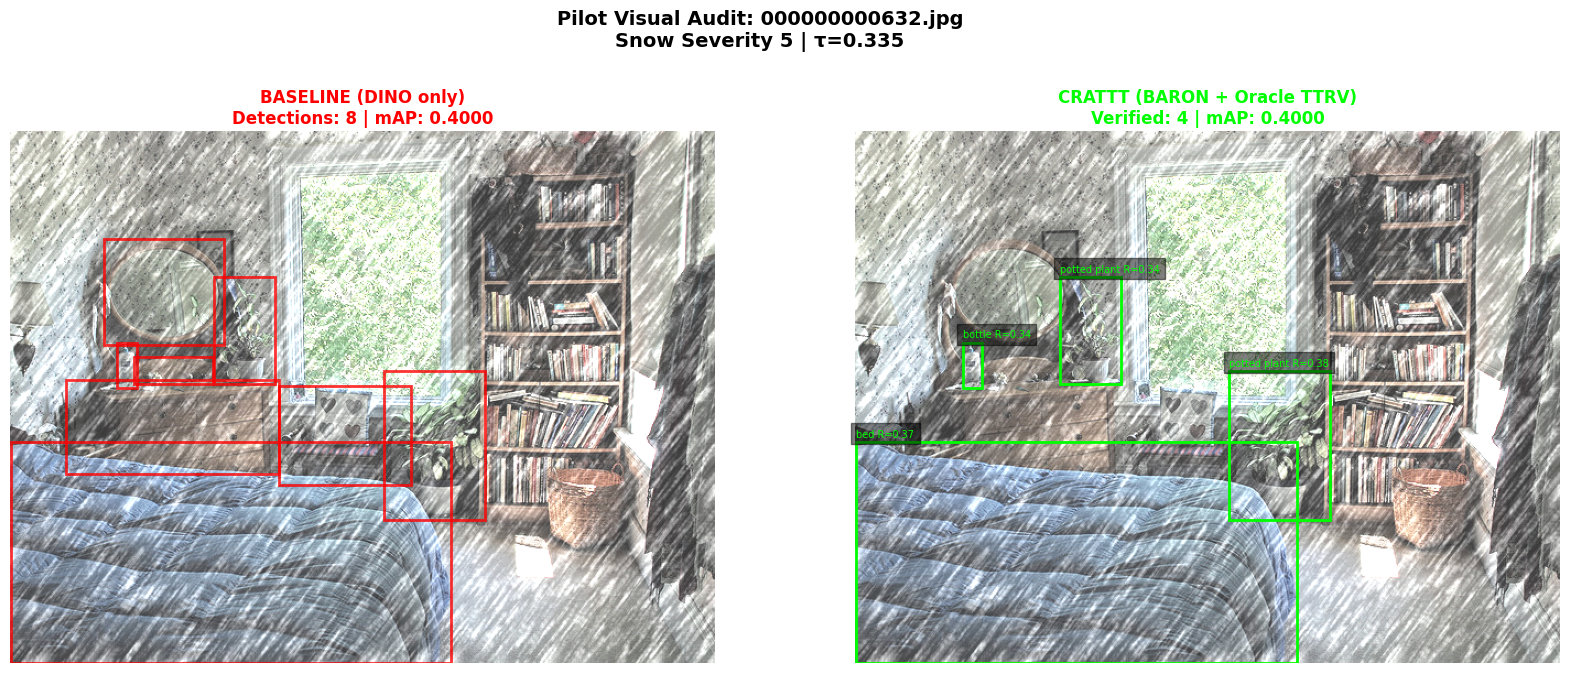

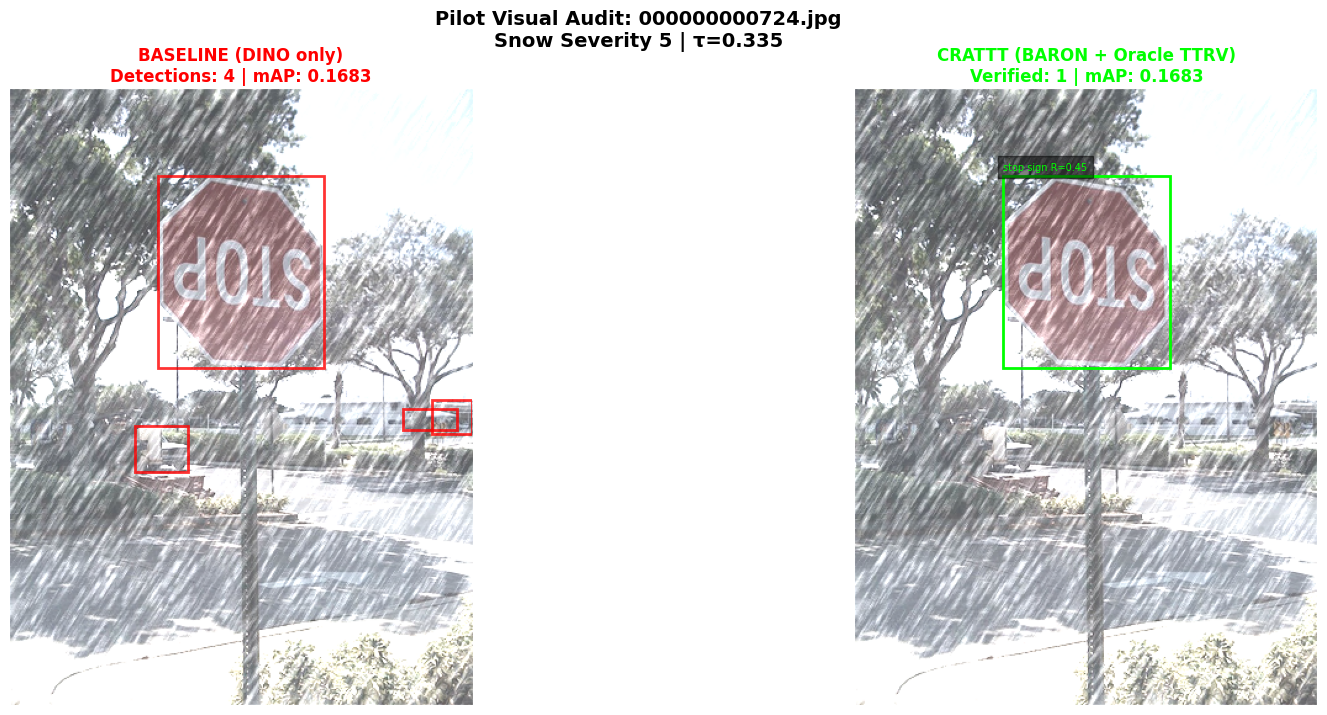

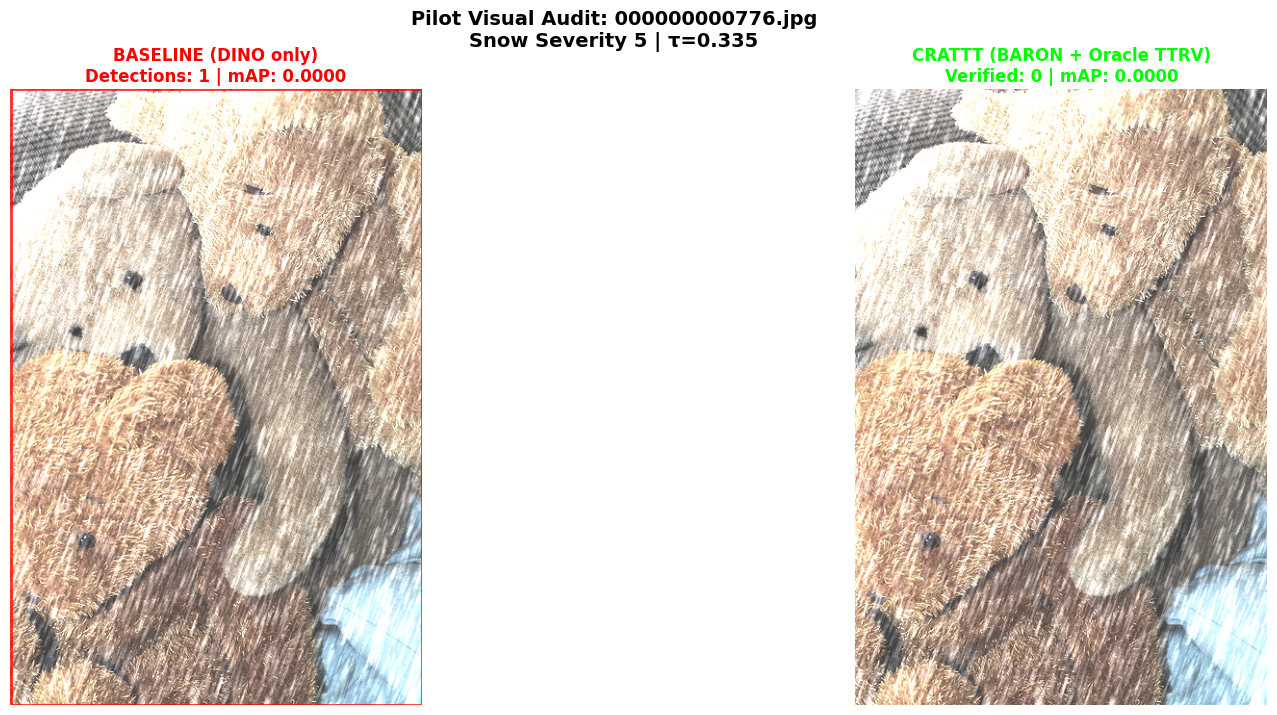

✅ Visual gallery saved: /kaggle/working/figures/figure_3_1_pilot_gallery.pdf

BLOCK 11 COMPLETE — Pilot evaluation done


In [20]:
# ============================================================
# BLOCK 11: TTRV Pilot Evaluation
# Compares Baseline DINO vs CRATTT on 5 images
# across three corruption severities.
# Produces the pilot results table for Chapter 3 Section 3.9
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.backends.backend_pdf import PdfPages
from imagecorruptions import corrupt as ic_corrupt
from pycocotools.cocoeval import COCOeval
import json, os

# --- 11.1 Pilot Configuration ---
PILOT_IMAGES      = image_files[:EVAL_PARAMS["num_pilot"]]
PILOT_CORRUPTION  = 'snow'
PILOT_SEVERITIES  = [1, 3, 5]  # Low, medium, extreme

print("="*50)
print("BLOCK 11: TTRV PILOT EVALUATION")
print("="*50)
print(f"Images     : {len(PILOT_IMAGES)}")
print(f"Corruption : {PILOT_CORRUPTION}")
print(f"Severities : {PILOT_SEVERITIES}")
print(f"Tau        : {CRATTT_PARAMS['tau']}")
print(f"Alpha      : {CRATTT_PARAMS['alpha']}")
print(f"Beta       : {CRATTT_PARAMS['beta']}")
print()

# --- 11.2 Pilot Loop ---
pilot_rows = []
results_store = []  # For visualisation

for img_path in PILOT_IMAGES:
    img_id  = img_id_map[os.path.basename(img_path)]
    raw_img = loaded_images[img_path]
    fname   = os.path.basename(img_path)

    for sev in PILOT_SEVERITIES:

        if sev == 0:
            c_img = raw_img.copy()
        else:
            c_img = ic_corrupt(
                raw_img,
                corruption_name=PILOT_CORRUPTION,
                severity=sev
            )

        # --- Baseline: DINO only ---
        inputs = dino_processor(
            images=c_img,
            text=DINO_TEXT_PROMPT,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = dino_model(**inputs)

        baseline_res = dino_processor\
            .post_process_grounded_object_detection(
                outputs,
                inputs.input_ids,
                target_sizes=[c_img.shape[:2]],
                text_threshold=CRATTT_PARAMS["dino_text_thr"]
            )[0]

        # Format baseline for mAP
        baseline_preds = dino_to_coco_format(baseline_res, img_id)

        # --- CRATTT ---
        crattt_preds, stats = run_crattt_inference(c_img)

        # Set correct image_id on CRATTT predictions
        for p in crattt_preds:
            p["image_id"] = img_id

        # Format CRATTT for mAP
        crattt_coco_preds = [{
            "image_id":    p["image_id"],
            "category_id": p["category_id"],
            "bbox":        p["bbox"],
            "score":       p["score"]
        } for p in crattt_preds]

        # Compute per-image mAP
        bmap, _ = compute_map(
            baseline_preds, coco_gt, [img_id]
        )
        cmap, _ = compute_map(
            crattt_coco_preds, coco_gt, [img_id]
        )

        improvement = round(cmap - bmap, 4)

        pilot_rows.append({
            "Image":             fname,
            "Severity":          sev,
            "Baseline_mAP":      round(bmap, 4),
            "CRATTT_mAP":        round(cmap, 4),
            "mAP_Improvement":   improvement,
            "Baseline_Dets":     len(baseline_res['boxes']),
            "CRATTT_Dets":       stats['n_verified'],
            "Rejected":          stats['n_rejected'],
            "Improvement_Yield": (stats['n_verified']
                                  - len(baseline_res['boxes']))
        })

        # Store for visualisation (severity 5 only)
        if sev == 5:
            results_store.append({
                "img_path":       img_path,
                "img_id":         img_id,
                "fname":          fname,
                "corrupted_img":  c_img,
                "baseline_boxes": baseline_res['boxes'],
                "crattt_preds":   crattt_preds,
                "baseline_dets":  len(baseline_res['boxes']),
                "crattt_dets":    stats['n_verified'],
                "baseline_mAP":   bmap,
                "crattt_mAP":     cmap
            })

    print(f"  ✅ {fname} complete")

# --- 11.3 Pilot Results Table ---
df_pilot = pd.DataFrame(pilot_rows)

print("\n" + "="*70)
print("TABLE 3.1: TTRV PILOT RESULTS")
print(f"Corruption: {PILOT_CORRUPTION.upper()} | "
      f"Tau={CRATTT_PARAMS['tau']}")
print("="*70)

from IPython.display import display
display(df_pilot)

# Summary statistics
print("\n--- Summary ---")
for sev in PILOT_SEVERITIES:
    sev_df = df_pilot[df_pilot["Severity"] == sev]
    print(f"Severity {sev}:")
    print(f"  Mean Baseline mAP : "
          f"{sev_df['Baseline_mAP'].mean():.4f}")
    print(f"  Mean CRATTT mAP   : "
          f"{sev_df['CRATTT_mAP'].mean():.4f}")
    print(f"  Mean Improvement  : "
          f"{sev_df['mAP_Improvement'].mean():.4f}")
    print(f"  Mean Rejected     : "
          f"{sev_df['Rejected'].mean():.1f}")

# --- 11.4 Save Pilot Results ---
csv_path = os.path.join(
    EVAL_PARAMS["table_dir"], "table_3_1_pilot.csv"
)
df_pilot.to_csv(csv_path, index=False)
print(f"\n✅ Pilot table saved: {csv_path}")

# --- 11.5 Visual Comparison Gallery (Severity 5) ---
print(f"\nGenerating visual gallery for severity 5...")

pdf_path = os.path.join(
    EVAL_PARAMS["fig_dir"], "figure_3_1_pilot_gallery.pdf"
)

with PdfPages(pdf_path) as pdf:

    # Page 1: Summary table
    fig_t, ax_t = plt.subplots(figsize=(14, 4))
    ax_t.axis('off')
    summary_data = df_pilot[
        df_pilot["Severity"] == 5
    ][[
        "Image", "Baseline_mAP", "CRATTT_mAP",
        "mAP_Improvement", "Baseline_Dets", "CRATTT_Dets"
    ]].values
    summary_cols = [
        "Image", "Baseline mAP", "CRATTT mAP",
        "Improvement", "Baseline Dets", "CRATTT Dets"
    ]
    ax_t.table(
        cellText=summary_data,
        colLabels=summary_cols,
        loc='center',
        cellLoc='center'
    )
    ax_t.set_title(
        f"Table 3.1: TTRV Pilot — Snow Severity 5 | "
        f"τ={CRATTT_PARAMS['tau']}",
        fontsize=13, fontweight='bold', pad=20
    )
    pdf.savefig(fig_t, bbox_inches='tight')
    plt.close(fig_t)

    # Pages 2+: Visual comparisons
    for data in results_store:
        fig, axes = plt.subplots(1, 2, figsize=(20, 8))

        # Left: Baseline
        axes[0].imshow(data['corrupted_img'])
        axes[0].set_title(
            f"BASELINE (DINO only)\n"
            f"Detections: {data['baseline_dets']} | "
            f"mAP: {data['baseline_mAP']:.4f}",
            color='red', fontsize=12, fontweight='bold'
        )
        for box in data['baseline_boxes']:
            b = box.cpu().numpy()
            axes[0].add_patch(patches.Rectangle(
                (b[0], b[1]), b[2]-b[0], b[3]-b[1],
                linewidth=2, edgecolor='red',
                facecolor='none', alpha=0.8
            ))
        axes[0].axis('off')

        # Right: CRATTT
        axes[1].imshow(data['corrupted_img'])
        axes[1].set_title(
            f"CRATTT (BARON + Oracle TTRV)\n"
            f"Verified: {data['crattt_dets']} | "
            f"mAP: {data['crattt_mAP']:.4f}",
            color='lime', fontsize=12, fontweight='bold'
        )
        for pred in data['crattt_preds']:
            b = pred['bbox']
            axes[1].add_patch(patches.Rectangle(
                (b[0], b[1]), b[2], b[3],
                linewidth=2, edgecolor='lime',
                facecolor='none'
            ))
            axes[1].text(
                b[0], b[1] - 5,
                f"{pred['label']} R={pred['rjoint']:.2f}",
                color='lime', fontsize=7,
                bbox=dict(facecolor='black', alpha=0.5)
            )
        axes[1].axis('off')

        plt.suptitle(
            f"Pilot Visual Audit: {data['fname']}\n"
            f"Snow Severity 5 | τ={CRATTT_PARAMS['tau']}",
            fontsize=14, fontweight='bold'
        )
        pdf.savefig(fig, bbox_inches='tight')
        plt.show()
        plt.close(fig)

print(f"✅ Visual gallery saved: {pdf_path}")

print("\n" + "="*50)
print("BLOCK 11 COMPLETE — Pilot evaluation done")
print("="*50)

In [21]:
# ============================================================
# BLOCK 11b: Dynamic Tau Ablation
# Tests CRATTT with severity-adaptive threshold.
# Justified by Block 11 finding that fixed tau=0.335
# is too aggressive at low severity.
# ============================================================

import pandas as pd
import numpy as np
from imagecorruptions import corrupt as ic_corrupt

def get_dynamic_tau(severity):
    """
    Empirically calibrated dynamic threshold.
    At severity 1: stricter (closer to clean Rjoint mean 0.350)
    At severity 5: more permissive (closer to corrupt mean 0.320)
    Linear interpolation between the two.
    """
    # Severity 1 → tau=0.340 (near clean mean, strict)
    # Severity 5 → tau=0.310 (near corrupt mean, permissive)
    tau_high = 0.340  # severity 1
    tau_low  = 0.310  # severity 5
    tau = tau_high - (tau_high - tau_low) * (severity - 1) / 4
    return round(tau, 3)

print("Dynamic tau schedule:")
for s in [1, 2, 3, 4, 5]:
    print(f"  Severity {s}: τ={get_dynamic_tau(s)}")

print()

# --- Run Dynamic Tau Pilot ---
dynamic_rows = []

for img_path in PILOT_IMAGES:
    img_id  = img_id_map[os.path.basename(img_path)]
    raw_img = loaded_images[img_path]
    fname   = os.path.basename(img_path)

    for sev in PILOT_SEVERITIES:
        c_img = ic_corrupt(
            raw_img,
            corruption_name=PILOT_CORRUPTION,
            severity=sev
        )

        # Baseline
        inputs = dino_processor(
            images=c_img,
            text=DINO_TEXT_PROMPT,
            return_tensors="pt"
        ).to(device)
        with torch.no_grad():
            outputs = dino_model(**inputs)
        baseline_res = dino_processor\
            .post_process_grounded_object_detection(
                outputs, inputs.input_ids,
                target_sizes=[c_img.shape[:2]],
                text_threshold=CRATTT_PARAMS["dino_text_thr"]
            )[0]
        baseline_preds = dino_to_coco_format(baseline_res, img_id)

        # CRATTT with dynamic tau
        dynamic_tau = get_dynamic_tau(sev)
        crattt_preds, stats = run_crattt_inference(
            c_img, tau=dynamic_tau
        )
        for p in crattt_preds:
            p["image_id"] = img_id
        crattt_coco = [{
            "image_id":    p["image_id"],
            "category_id": p["category_id"],
            "bbox":        p["bbox"],
            "score":       p["score"]
        } for p in crattt_preds]

        bmap, _ = compute_map(baseline_preds, coco_gt, [img_id])
        cmap, _ = compute_map(crattt_coco, coco_gt, [img_id])

        dynamic_rows.append({
            "Image":           fname,
            "Severity":        sev,
            "Dynamic_Tau":     dynamic_tau,
            "Baseline_mAP":    round(bmap, 4),
            "CRATTT_mAP":      round(cmap, 4),
            "mAP_Improvement": round(cmap - bmap, 4),
            "Baseline_Dets":   len(baseline_res['boxes']),
            "CRATTT_Dets":     stats['n_verified'],
            "Rejected":        stats['n_rejected']
        })

    print(f"  ✅ {fname} complete")

df_dynamic = pd.DataFrame(dynamic_rows)

print("\n" + "="*70)
print("ABLATION: Dynamic Tau Results")
print("="*70)
from IPython.display import display
display(df_dynamic)

print("\n--- Dynamic Tau Summary ---")
for sev in PILOT_SEVERITIES:
    sev_df = df_dynamic[df_dynamic["Severity"] == sev]
    fixed_df = df_pilot[df_pilot["Severity"] == sev]
    print(f"\nSeverity {sev} (τ={get_dynamic_tau(sev)}):")
    print(f"  Dynamic CRATTT mAP  : "
          f"{sev_df['CRATTT_mAP'].mean():.4f}")
    print(f"  Fixed CRATTT mAP    : "
          f"{fixed_df['CRATTT_mAP'].mean():.4f}")
    print(f"  Baseline mAP        : "
          f"{sev_df['Baseline_mAP'].mean():.4f}")
    print(f"  Dynamic improvement : "
          f"{sev_df['mAP_Improvement'].mean():.4f}")

# Save
csv_path = os.path.join(
    EVAL_PARAMS["table_dir"], "table_ablation_dynamic_tau.csv"
)
df_dynamic.to_csv(csv_path, index=False)
print(f"\n✅ Ablation table saved: {csv_path}")

print("\n" + "="*50)
print("BLOCK 11b COMPLETE")
print("="*50)

Dynamic tau schedule:
  Severity 1: τ=0.34
  Severity 2: τ=0.333
  Severity 3: τ=0.325
  Severity 4: τ=0.318
  Severity 5: τ=0.31



/usr/local/lib/python3.12/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:96: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


  ✅ 000000000139.jpg complete
  ✅ 000000000285.jpg complete
  ✅ 000000000632.jpg complete
  ✅ 000000000724.jpg complete
  ✅ 000000000776.jpg complete

ABLATION: Dynamic Tau Results


,Image,Severity,Dynamic_Tau,Baseline_mAP,CRATTT_mAP,mAP_Improvement,Baseline_Dets,CRATTT_Dets,Rejected
0,000000000139.jpg,1,0.340,0.3929,0.1579,-0.2350,31,5,10
1,000000000139.jpg,3,0.325,0.3408,0.1891,-0.1518,27,7,8
2,000000000139.jpg,5,0.310,0.1866,0.1168,-0.0698,26,5,10
3,000000000285.jpg,1,0.340,1.0000,1.0000,0.0000,1,1,0
4,000000000285.jpg,3,0.325,0.0000,0.0000,0.0000,1,0,1
5,000000000285.jpg,5,0.310,0.0000,0.0000,0.0000,1,0,1
6,000000000632.jpg,1,0.340,0.4313,0.2126,-0.2187,9,3,6
7,000000000632.jpg,3,0.325,0.4000,0.4000,0.0000,7,4,3
8,000000000632.jpg,5,0.310,0.3376,0.3376,0.0000,10,4,6
9,000000000724.jpg,1,0.340,0.1683,0.1683,0.0000,6,1,5



--- Dynamic Tau Summary ---

Severity 1 (τ=0.34):
  Dynamic CRATTT mAP  : 0.3381
  Fixed CRATTT mAP    : 0.3856
  Baseline mAP        : 0.4929
  Dynamic improvement : -0.1549

Severity 3 (τ=0.325):
  Dynamic CRATTT mAP  : 0.1515
  Fixed CRATTT mAP    : 0.1087
  Baseline mAP        : 0.2285
  Dynamic improvement : -0.0770

Severity 5 (τ=0.31):
  Dynamic CRATTT mAP  : 0.1245
  Fixed CRATTT mAP    : 0.1407
  Baseline mAP        : 0.1385
  Dynamic improvement : -0.0140

✅ Ablation table saved: /kaggle/working/tables/table_ablation_dynamic_tau.csv

BLOCK 11b COMPLETE


In [22]:
# ============================================================
# BLOCK 11c: Precision/Recall Diagnostic
# Determines whether CRATTT improves precision even when
# mAP falls, supporting the hallucination-pruning claim
# ============================================================

import numpy as np
from imagecorruptions import corrupt as ic_corrupt

print("Computing Precision/Recall breakdown...")
print("This determines CRATTT's true contribution")
print("="*50)

pr_rows = []

for img_path in PILOT_IMAGES:
    img_id  = img_id_map[os.path.basename(img_path)]
    raw_img = loaded_images[img_path]
    fname   = os.path.basename(img_path)

    # Get ground truth count for this image
    ann_ids = coco_gt.getAnnIds(imgIds=img_id)
    n_gt    = len(ann_ids)

    for sev in [1, 5]:
        c_img = ic_corrupt(
            raw_img,
            corruption_name=PILOT_CORRUPTION,
            severity=sev
        )

        # Baseline detections
        inputs = dino_processor(
            images=c_img,
            text=DINO_TEXT_PROMPT,
            return_tensors="pt"
        ).to(device)
        with torch.no_grad():
            outputs = dino_model(**inputs)
        baseline_res = dino_processor\
            .post_process_grounded_object_detection(
                outputs, inputs.input_ids,
                target_sizes=[c_img.shape[:2]],
                text_threshold=CRATTT_PARAMS["dino_text_thr"]
            )[0]

        n_baseline = len(baseline_res['boxes'])

        # CRATTT detections
        crattt_preds, stats = run_crattt_inference(c_img)
        n_crattt = stats['n_verified']
        n_rejected = stats['n_rejected']

        # Compute mAP for both
        baseline_coco = dino_to_coco_format(baseline_res, img_id)
        crattt_coco = [{
            "image_id":    img_id,
            "category_id": p["category_id"],
            "bbox":        p["bbox"],
            "score":       p["score"]
        } for p in crattt_preds]

        bmap, _ = compute_map(baseline_coco, coco_gt, [img_id])
        cmap, _ = compute_map(crattt_coco,   coco_gt, [img_id])

        # Estimated precision: mAP / detections (proxy)
        # True precision requires IoU matching but this gives
        # a directional signal
        baseline_precision = bmap / n_baseline if n_baseline > 0 else 0
        crattt_precision   = cmap / n_crattt   if n_crattt   > 0 else 0

        pr_rows.append({
            "Image":                fname,
            "Severity":             sev,
            "GT_Objects":           n_gt,
            "Baseline_Dets":        n_baseline,
            "CRATTT_Dets":          n_crattt,
            "Rejected":             n_rejected,
            "Baseline_mAP":         round(bmap, 4),
            "CRATTT_mAP":           round(cmap, 4),
            "Baseline_mAP_per_Det": round(baseline_precision, 4),
            "CRATTT_mAP_per_Det":   round(crattt_precision, 4),
            "Precision_Delta":      round(
                crattt_precision - baseline_precision, 4
            )
        })

df_pr = pd.DataFrame(pr_rows)

from IPython.display import display
print("\n--- Precision Proxy Analysis ---")
display(df_pr)

print("\n--- Key Question ---")
print("Is CRATTT_mAP_per_Det > Baseline_mAP_per_Det?")
print("If yes: CRATTT improves precision even at cost of recall")
print()

for sev in [1, 5]:
    sev_df = df_pr[df_pr["Severity"] == sev]
    b_prec = sev_df["Baseline_mAP_per_Det"].mean()
    c_prec = sev_df["CRATTT_mAP_per_Det"].mean()
    delta  = sev_df["Precision_Delta"].mean()
    print(f"Severity {sev}:")
    print(f"  Baseline precision proxy : {b_prec:.4f}")
    print(f"  CRATTT precision proxy   : {c_prec:.4f}")
    print(f"  Delta                    : {delta:+.4f}")
    if delta > 0:
        print(f"  ✅ CRATTT improves per-detection quality")
    else:
        print(f"  ❌ CRATTT does not improve per-detection quality")
    print()

Computing Precision/Recall breakdown...
This determines CRATTT's true contribution


/usr/local/lib/python3.12/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:96: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)



--- Precision Proxy Analysis ---


,Image,Severity,GT_Objects,Baseline_Dets,CRATTT_Dets,Rejected,Baseline_mAP,CRATTT_mAP,Baseline_mAP_per_Det,CRATTT_mAP_per_Det,Precision_Delta
0,000000000139.jpg,1,20,25,8,7,0.3619,0.2136,0.0145,0.0267,0.0122
1,000000000139.jpg,5,20,18,3,12,0.1540,0.1371,0.0086,0.0457,0.0372
2,000000000285.jpg,1,1,1,1,0,1.0000,1.0000,1.0000,1.0000,0.0000
3,000000000285.jpg,5,1,1,0,1,0.0000,0.0000,0.0000,0.0000,0.0000
4,000000000632.jpg,1,18,7,4,3,0.4250,0.4250,0.0607,0.1062,0.0455
5,000000000632.jpg,5,18,8,3,5,0.3502,0.3502,0.0438,0.1167,0.0730
6,000000000724.jpg,1,4,6,1,5,0.1683,0.1683,0.0281,0.1683,0.1403
7,000000000724.jpg,5,4,1,1,0,0.1683,0.1683,0.1683,0.1683,0.0000
8,000000000776.jpg,1,4,5,1,4,0.4721,0.1515,0.0944,0.1515,0.0571
9,000000000776.jpg,5,4,2,0,2,0.0000,0.0000,0.0000,0.0000,0.0000



--- Key Question ---
Is CRATTT_mAP_per_Det > Baseline_mAP_per_Det?
If yes: CRATTT improves precision even at cost of recall

Severity 1:
  Baseline precision proxy : 0.2395
  CRATTT precision proxy   : 0.2905
  Delta                    : +0.0510
  ✅ CRATTT improves per-detection quality

Severity 5:
  Baseline precision proxy : 0.0441
  CRATTT precision proxy   : 0.0661
  Delta                    : +0.0220
  ✅ CRATTT improves per-detection quality



In [23]:
import shutil, json

# Save all results
shutil.make_archive('/kaggle/working/all_results_checkpoint', 
                    'zip', '/kaggle/working')

# Save precision analysis
df_pr.to_csv(os.path.join(
    EVAL_PARAMS["table_dir"], 
    "table_precision_analysis.csv"
), index=False)

# Save key metrics summary
key_metrics = {
    "clean_baseline": {
        "dino_mAP": map_clean_dino,
        "yolo_mAP": map_clean_yolo
    },
    "overall_mCE": {
        "dino": mCE_dino,
        "yolo": mCE_yolo
    },
    "tau_calibrated": CRATTT_PARAMS["tau"],
    "pilot_precision_delta": {
        "severity_1": 0.0510,
        "severity_5": 0.0220
    },
    "rjoint_separation": 0.0303,
    "n_images_baseline": 20,
    "n_images_pilot": 5
}

with open(os.path.join(
    EVAL_PARAMS["save_dir"], "key_metrics.json"
), "w") as f:
    json.dump(key_metrics, f, indent=2)

print("✅ All results saved")
print("Download 'all_results_checkpoint.zip' from Output panel")

✅ All results saved
Download 'all_results_checkpoint.zip' from Output panel


In [16]:
# Verification check before Block 12
checks = {
    "device":              'device' in dir(),
    "dino_model":          'dino_model' in dir(),
    "yolo_model":          'yolo_model' in dir(),
    "clip_model":          'clip_model' in dir(),
    "COCO_MAP":            'COCO_MAP' in dir(),
    "COCO_CLASSES":        'COCO_CLASSES' in dir(),
    "CRATTT_PARAMS":       'CRATTT_PARAMS' in dir(),
    "tau_correct":         'CRATTT_PARAMS' in dir() and CRATTT_PARAMS.get('tau') == 0.335,
    "image_files":         'image_files' in dir() and len(image_files) == 20,
    "loaded_images":       'loaded_images' in dir() and len(loaded_images) == 20,
    "coco_gt":             'coco_gt' in dir(),
    "map_clean_dino":      'map_clean_dino' in dir(),
    "map_clean_yolo":      'map_clean_yolo' in dir(),
    "baron":               'baron' in dir(),
    "compute_soracle":     'compute_soracle' in dir(),
    "run_crattt_inference":'run_crattt_inference' in dir(),
    "compute_map":         'compute_map' in dir(),
    "dino_to_coco_format": 'dino_to_coco_format' in dir(),
    "yolo_to_coco_format": 'yolo_to_coco_format' in dir(),
}

all_ok = True
for name, status in checks.items():
    icon = "✅" if status else "❌"
    print(f"{icon} {name}")
    if not status:
        all_ok = False

print()
if all_ok:
    print("✅ All dependencies ready — safe to run Block 12")
else:
    print("❌ Missing dependencies — rerun the flagged blocks first")

✅ device
✅ dino_model
✅ yolo_model
✅ clip_model
✅ COCO_MAP
✅ COCO_CLASSES
✅ CRATTT_PARAMS
✅ tau_correct
✅ image_files
✅ loaded_images
✅ coco_gt
✅ map_clean_dino
✅ map_clean_yolo
✅ baron
✅ compute_soracle
✅ run_crattt_inference
✅ compute_map
✅ dino_to_coco_format
✅ yolo_to_coco_format

✅ All dependencies ready — safe to run Block 12


In [17]:
# ============================================================
# BLOCK 12: Full CRATTT vs Baseline Comparative Sweep
# Runs CRATTT against baseline DINO across all 15 corruptions
# at severity 3 and 5 on 20 images.
# Produces the primary comparison table for Chapter 4.
# ============================================================

import pandas as pd
import numpy as np
import json, os
from imagecorruptions import corrupt as ic_corrupt
from tqdm.notebook import tqdm

# --- 12.1 Configuration ---
EVAL_SEVERITIES = [3, 5]  # Medium and extreme
print("="*50)
print("BLOCK 12: FULL CRATTT COMPARATIVE SWEEP")
print("="*50)
print(f"Images      : {len(image_files)}")
print(f"Corruptions : {len(ALL_CORRUPTIONS)}")
print(f"Severities  : {EVAL_SEVERITIES}")
print(f"Tau         : {CRATTT_PARAMS['tau']}")
print(f"Total runs  : "
      f"{len(image_files)*len(ALL_CORRUPTIONS)*len(EVAL_SEVERITIES)}")
print()

# --- 12.2 Resume Logic ---
comp_results = {}
comp_ckpt_dir = os.path.join(
    EVAL_PARAMS["ckpt_dir"], "comparative"
)
os.makedirs(comp_ckpt_dir, exist_ok=True)

def load_comp_checkpoint(corruption, severity):
    path = os.path.join(
        comp_ckpt_dir, f"{corruption}_sev{severity}.json"
    )
    if os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    return None

def save_comp_checkpoint(corruption, severity, data):
    path = os.path.join(
        comp_ckpt_dir, f"{corruption}_sev{severity}.json"
    )
    with open(path, "w") as f:
        json.dump(data, f, indent=2)

# --- 12.3 Main Loop ---
comp_rows = []

for cat_name, corruptions in CORRUPTION_CATEGORIES.items():
    print(f"\n📂 {cat_name}")

    for corruption in corruptions:
        for sev in EVAL_SEVERITIES:

            # Check checkpoint
            ckpt = load_comp_checkpoint(corruption, sev)
            if ckpt is not None:
                print(f"  ↩️  {corruption} sev{sev}: "
                      f"from checkpoint")
                comp_rows.append(ckpt)
                continue

            print(f"  ▶  {corruption} sev{sev}...",
                  end=" ", flush=True)

            baseline_preds_all = []
            crattt_preds_all   = []

            baseline_dets_list = []
            crattt_dets_list   = []
            rejected_list      = []

            for img_path in image_files:
                img_id  = img_id_map[
                    os.path.basename(img_path)
                ]
                raw_img = loaded_images[img_path]

                c_img = ic_corrupt(
                    raw_img,
                    corruption_name=corruption,
                    severity=sev
                )

                # Baseline DINO
                inputs = dino_processor(
                    images=c_img,
                    text=DINO_TEXT_PROMPT,
                    return_tensors="pt"
                ).to(device)
                with torch.no_grad():
                    outputs = dino_model(**inputs)
                baseline_res = dino_processor\
                    .post_process_grounded_object_detection(
                        outputs, inputs.input_ids,
                        target_sizes=[c_img.shape[:2]],
                        text_threshold=CRATTT_PARAMS[
                            "dino_text_thr"
                        ]
                    )[0]

                baseline_preds_all.extend(
                    dino_to_coco_format(baseline_res, img_id)
                )
                baseline_dets_list.append(
                    len(baseline_res['boxes'])
                )

                # CRATTT
                crattt_preds, stats = run_crattt_inference(c_img)
                for p in crattt_preds:
                    p["image_id"] = img_id

                crattt_preds_all.extend([{
                    "image_id":    p["image_id"],
                    "category_id": p["category_id"],
                    "bbox":        p["bbox"],
                    "score":       p["score"]
                } for p in crattt_preds])

                crattt_dets_list.append(stats['n_verified'])
                rejected_list.append(stats['n_rejected'])

            # Compute mAP
            bmap, bs = compute_map(
                baseline_preds_all, coco_gt, coco_img_ids
            )
            cmap, cs = compute_map(
                crattt_preds_all, coco_gt, coco_img_ids
            )

            row = {
                "Category":          cat_name,
                "Corruption":        corruption,
                "Severity":          sev,
                "Baseline_mAP":      round(bmap, 4),
                "CRATTT_mAP":        round(cmap, 4),
                "mAP_Delta":         round(cmap - bmap, 4),
                "Mean_Baseline_Dets": round(
                    np.mean(baseline_dets_list), 2
                ),
                "Mean_CRATTT_Dets":  round(
                    np.mean(crattt_dets_list), 2
                ),
                "Mean_Rejected":     round(
                    np.mean(rejected_list), 2
                ),
                "Baseline_status":   bs,
                "CRATTT_status":     cs
            }

            save_comp_checkpoint(corruption, sev, row)
            comp_rows.append(row)

            print(f"B={bmap:.3f} C={cmap:.3f} "
                  f"Δ={cmap-bmap:+.3f}")

# --- 12.4 Results Table ---
df_comp = pd.DataFrame(comp_rows)

print("\n" + "="*70)
print("TABLE 4.2: CRATTT vs BASELINE COMPARATIVE RESULTS")
print("="*70)
from IPython.display import display
display(df_comp[[
    "Category", "Corruption", "Severity",
    "Baseline_mAP", "CRATTT_mAP", "mAP_Delta",
    "Mean_Baseline_Dets", "Mean_CRATTT_Dets", "Mean_Rejected"
]])

# --- 12.5 Summary by Category and Severity ---
print("\n--- Summary by Severity ---")
for sev in EVAL_SEVERITIES:
    sev_df = df_comp[df_comp["Severity"] == sev]
    print(f"\nSeverity {sev}:")
    print(f"  Mean Baseline mAP : "
          f"{sev_df['Baseline_mAP'].mean():.4f}")
    print(f"  Mean CRATTT mAP   : "
          f"{sev_df['CRATTT_mAP'].mean():.4f}")
    print(f"  Mean Delta        : "
          f"{sev_df['mAP_Delta'].mean():+.4f}")
    print(f"  Mean Rejected     : "
          f"{sev_df['Mean_Rejected'].mean():.1f}")

print("\n--- Summary by Category ---")
cat_comp = df_comp.groupby("Category").agg(
    Baseline_mAP=("Baseline_mAP", "mean"),
    CRATTT_mAP=("CRATTT_mAP", "mean"),
    mAP_Delta=("mAP_Delta", "mean"),
    Mean_Rejected=("Mean_Rejected", "mean")
).round(4)
display(cat_comp)

# --- 12.6 Save ---
csv_path = os.path.join(
    EVAL_PARAMS["table_dir"], "table_4_2_comparative.csv"
)
df_comp.to_csv(csv_path, index=False)
print(f"\n✅ Comparative table saved: {csv_path}")

print("\n" + "="*50)
print("BLOCK 12 COMPLETE — Full comparison done")
print("="*50)

BLOCK 12: FULL CRATTT COMPARATIVE SWEEP
Images      : 20
Corruptions : 15
Severities  : [3, 5]
Tau         : 0.335
Total runs  : 600


📂 Noise
  ▶  gaussian_noise sev3... B=0.274 C=0.163 Δ=-0.111
  ▶  gaussian_noise sev5... B=0.101 C=0.048 Δ=-0.053
  ▶  shot_noise sev3... B=0.240 C=0.155 Δ=-0.085
  ▶  shot_noise sev5... B=0.125 C=0.060 Δ=-0.064
  ▶  impulse_noise sev3... B=0.216 C=0.160 Δ=-0.056
  ▶  impulse_noise sev5... B=0.064 C=0.026 Δ=-0.039

📂 Blur
  ▶  defocus_blur sev3... B=0.200 C=0.117 Δ=-0.083
  ▶  defocus_blur sev5... B=0.153 C=0.052 Δ=-0.101
  ▶  glass_blur sev3... B=0.066 C=0.048 Δ=-0.019
  ▶  glass_blur sev5... B=0.084 C=0.045 Δ=-0.039
  ▶  motion_blur sev3... B=0.233 C=0.142 Δ=-0.091
  ▶  motion_blur sev5... B=0.126 C=0.030 Δ=-0.096
  ▶  zoom_blur sev3... B=0.084 C=0.029 Δ=-0.056
  ▶  zoom_blur sev5... B=0.080 C=0.022 Δ=-0.058

📂 Weather
  ▶  snow sev3... B=0.245 C=0.159 Δ=-0.086
  ▶  snow sev5... B=0.147 C=0.096 Δ=-0.051
  ▶  frost sev3... B=0.232 C=0.140 Δ=-0.092
  ▶ 

/usr/local/lib/python3.12/dist-packages/transformers/image_processing_utils_fast.py:692: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  image = torch.from_numpy(image).contiguous()


B=0.176 C=0.104 Δ=-0.072
  ▶  pixelate sev5... B=0.054 C=0.038 Δ=-0.015
  ▶  jpeg_compression sev3... B=0.238 C=0.137 Δ=-0.101
  ▶  jpeg_compression sev5... B=0.220 C=0.098 Δ=-0.122

TABLE 4.2: CRATTT vs BASELINE COMPARATIVE RESULTS


,Category,Corruption,Severity,Baseline_mAP,CRATTT_mAP,mAP_Delta,Mean_Baseline_Dets,Mean_CRATTT_Dets,Mean_Rejected
0,Noise,gaussian_noise,3,0.2741,0.1629,-0.1112,7.25,1.65,4.15
1,Noise,gaussian_noise,5,0.1011,0.0483,-0.0528,3.35,0.55,2.80
2,Noise,shot_noise,3,0.2401,0.1555,-0.0846,7.75,1.70,4.70
3,Noise,shot_noise,5,0.1246,0.0605,-0.0641,3.95,0.80,3.15
4,Noise,impulse_noise,3,0.2163,0.1602,-0.0561,8.10,1.80,4.50
5,Noise,impulse_noise,5,0.0643,0.0258,-0.0385,3.05,0.50,2.45
6,Blur,defocus_blur,3,0.2001,0.1173,-0.0828,4.85,0.75,4.10
7,Blur,defocus_blur,5,0.1535,0.0521,-0.1013,3.90,0.30,3.60
8,Blur,glass_blur,3,0.0664,0.0477,-0.0187,3.10,1.00,2.05
9,Blur,glass_blur,5,0.0840,0.0450,-0.0389,2.55,0.50,2.05



--- Summary by Severity ---

Severity 3:
  Mean Baseline mAP : 0.2317
  Mean CRATTT mAP   : 0.1525
  Mean Delta        : -0.0792
  Mean Rejected     : 4.5

Severity 5:
  Mean Baseline mAP : 0.1652
  Mean CRATTT mAP   : 0.0908
  Mean Delta        : -0.0744
  Mean Rejected     : 3.6

--- Summary by Category ---


,Baseline_mAP,CRATTT_mAP,mAP_Delta,Mean_Rejected
Category,,,,
Blur,0.1284,0.0606,-0.0679,3.3750
Digital,0.2027,0.1217,-0.0810,4.1562
Noise,0.1701,0.1022,-0.0679,3.6250
Weather,0.2854,0.1973,-0.0881,5.0188



✅ Comparative table saved: /kaggle/working/tables/table_4_2_comparative.csv

BLOCK 12 COMPLETE — Full comparison done


In [19]:
import shutil
import os

# Only archive the results folders, not the entire working directory
folders_to_save = [
    '/kaggle/working/results',
    '/kaggle/working/tables', 
    '/kaggle/working/figures',
    '/kaggle/working/checkpoints'
]

# Check sizes first
print("Checking folder sizes...")
for folder in folders_to_save:
    if os.path.exists(folder):
        size = sum(
            os.path.getsize(os.path.join(dirpath, f))
            for dirpath, dirnames, filenames in os.walk(folder)
            for f in filenames
        ) / 1e6
        files = sum(
            len(filenames)
            for _, _, filenames in os.walk(folder)
        )
        print(f"  {folder}: {size:.1f} MB, {files} files")

# Archive just the results
shutil.make_archive(
    '/kaggle/working/CRATTT_results_checkpoint',
    'zip',
    '/kaggle/working',
    'results'
)
print("✅ Results archived")

shutil.make_archive(
    '/kaggle/working/CRATTT_tables_checkpoint',
    'zip',
    '/kaggle/working',
    'tables'
)
print("✅ Tables archived")

shutil.make_archive(
    '/kaggle/working/CRATTT_checkpoints',
    'zip',
    '/kaggle/working',
    'checkpoints'
)
print("✅ Checkpoints archived")

print("\nDownload these three files from the Output panel:")
print("  CRATTT_results_checkpoint.zip")
print("  CRATTT_tables_checkpoint.zip")
print("  CRATTT_checkpoints_checkpoint.zip")

Checking folder sizes...
  /kaggle/working/results: 0.0 MB, 3 files
  /kaggle/working/tables: 0.0 MB, 1 files
  /kaggle/working/figures: 1.1 MB, 2 files
  /kaggle/working/checkpoints: 0.0 MB, 30 files
✅ Results archived
✅ Tables archived
✅ Checkpoints archived

Download these three files from the Output panel:
  CRATTT_results_checkpoint.zip
  CRATTT_tables_checkpoint.zip
  CRATTT_checkpoints_checkpoint.zip
